# Кластеризация

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('syntax_features.csv')

In [ ]:
feature_cols = [col for col in df.columns if any(col.startswith(prefix) for prefix in
    ['tree_depth', 'dep_distance', 'clauses', 'amod_chain', 'advcl', 'participles',
     'relcl', 'verbal_adverbs', 'ccomp', 'infinitive_phrases', 'nmod'])]
print(f'Найдено признаков: {len(feature_cols)}')
df = df[feature_cols].copy()
df.head()

Найдено признаков: 44


,tree_depth_mean,tree_depth_median,tree_depth_max,tree_depth_std,dep_distance_mean,dep_distance_median,dep_distance_max,dep_distance_std,clauses_mean,clauses_median,...,ccomp_max,ccomp_std,infinitive_phrases_mean,infinitive_phrases_median,infinitive_phrases_max,infinitive_phrases_std,nmod_mean,nmod_median,nmod_max,nmod_std
0,3.750000,3.0,6.0,1.500000,2.707317,1.0,21.0,3.501742,1.500000,1.0,...,0.0,0.00000,0.5,0.0,2.0,1.000000,0.25,0.0,1.0,0.500000
1,2.666667,2.5,4.0,1.211060,2.242424,1.0,10.0,2.669624,1.833333,1.0,...,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00,0.0,0.0,0.000000
2,3.600000,4.0,4.0,0.547723,2.791667,1.0,19.0,3.946225,1.800000,1.0,...,0.0,0.00000,0.0,0.0,0.0,0.000000,0.00,0.0,0.0,0.000000
3,4.200000,3.0,9.0,2.774887,2.545455,1.0,25.0,3.625109,2.000000,1.0,...,0.0,0.00000,0.2,0.0,1.0,0.447214,1.00,0.0,4.0,1.732051
4,3.428571,3.0,7.0,1.988060,2.850746,2.0,26.0,3.778944,2.000000,1.0,...,1.0,0.48795,0.0,0.0,0.0,0.000000,0.00,0.0,0.0,0.000000


In [ ]:
df.shape

(1888, 44)

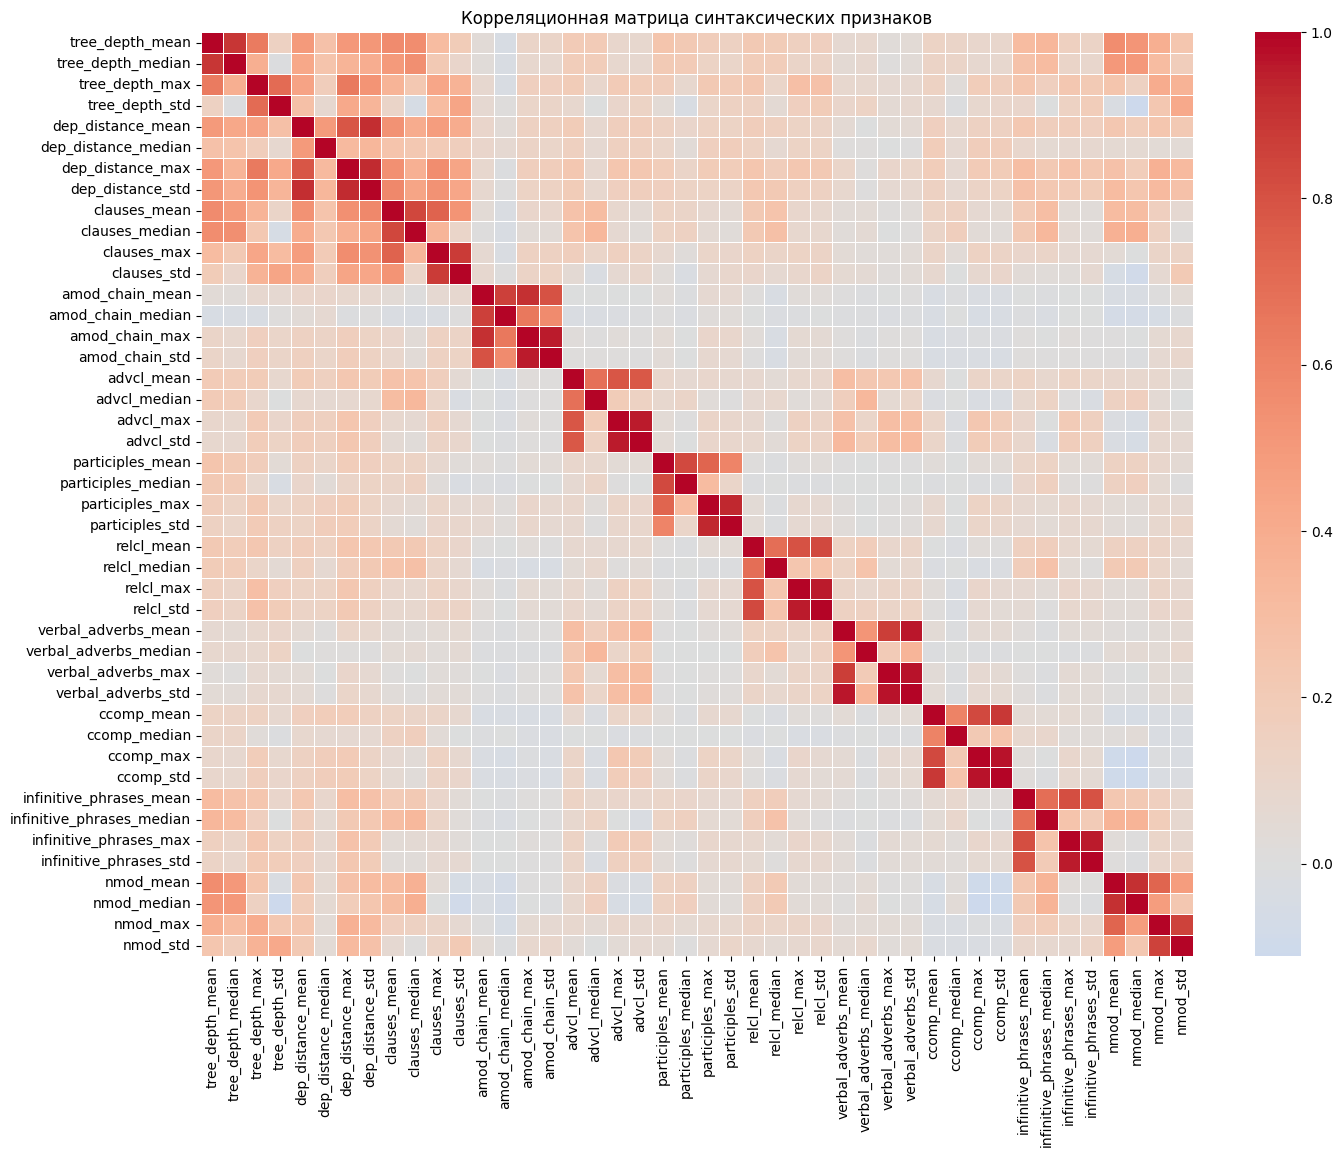

In [ ]:
# Вычислим корреляцию
corr_matrix = X.corr()

# Визуализируем heatmap (может быть большой, поэтому можно показать только часть)
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Корреляционная матрица синтаксических признаков')
plt.show()

In [ ]:
threshold = 0.95
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f'Найдено {len(high_corr_pairs)} пар с корреляцией > {threshold}')
for pair in high_corr_pairs:
    print(f'{pair[0]} ↔ {pair[1]}: {pair[2]:.3f}')

Найдено 7 пар с корреляцией > 0.95
amod_chain_max ↔ amod_chain_std: 0.952
advcl_max ↔ advcl_std: 0.955
relcl_max ↔ relcl_std: 0.953
verbal_adverbs_mean ↔ verbal_adverbs_std: 0.964
verbal_adverbs_max ↔ verbal_adverbs_std: 0.968
ccomp_max ↔ ccomp_std: 0.966
infinitive_phrases_max ↔ infinitive_phrases_std: 0.955


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

df = df.copy()
for col in feature_cols:
    df[col + '_scaled'] = X_scaled_df[col]

print('Масштабирование выполнено.')
X_scaled_df.head()

Масштабирование выполнено.


,tree_depth_mean,tree_depth_median,tree_depth_max,tree_depth_std,dep_distance_mean,dep_distance_median,dep_distance_max,dep_distance_std,clauses_mean,clauses_median,...,ccomp_max,ccomp_std,infinitive_phrases_mean,infinitive_phrases_median,infinitive_phrases_max,infinitive_phrases_std,nmod_mean,nmod_median,nmod_max,nmod_std
0,0.149298,-0.549514,0.542752,0.370349,0.337649,-0.649252,0.594285,0.306488,-0.242122,-0.403733,...,-0.384874,-0.369064,2.986647,-0.091559,3.397052,3.835927,-0.460410,-0.467963,-0.419095,-0.250047
1,-1.194805,-1.098736,-0.968628,-0.074043,-0.353890,-0.649252,-0.621208,-0.289106,0.210380,-0.403733,...,-0.384874,-0.369064,-0.292351,-0.091559,-0.382343,-0.348533,-0.822697,-0.467963,-1.190296,-1.072540
2,-0.036808,0.548932,-0.968628,-1.094263,0.463122,-0.649252,0.373287,0.624630,0.165130,-0.403733,...,-0.384874,-0.369064,-0.292351,-0.091559,-0.382343,-0.348533,-0.822697,-0.467963,-1.190296,-1.072540
3,0.707619,-0.549514,2.809820,2.331137,0.096875,-0.649252,1.036283,0.394789,0.436632,-0.403733,...,-0.384874,-0.369064,1.019248,-0.091559,1.507354,1.522815,0.626451,-0.467963,1.894507,1.776660
4,-0.249502,-0.549514,1.298441,1.120989,0.551004,1.614437,1.146782,0.504897,0.436632,-0.403733,...,2.238383,2.670040,-0.292351,-0.091559,-0.382343,-0.348533,-0.822697,-0.467963,-1.190296,-1.072540


In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled_df)

print(f'Исходная размерность: {X_scaled_df.shape[1]}')
print(f'Размерность после PCA: {X_pca.shape[1]}')
print(f'Объяснённая дисперсия: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}')

pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=X.index)

Исходная размерность: 44
Размерность после PCA: 20
Объяснённая дисперсия: 0.952


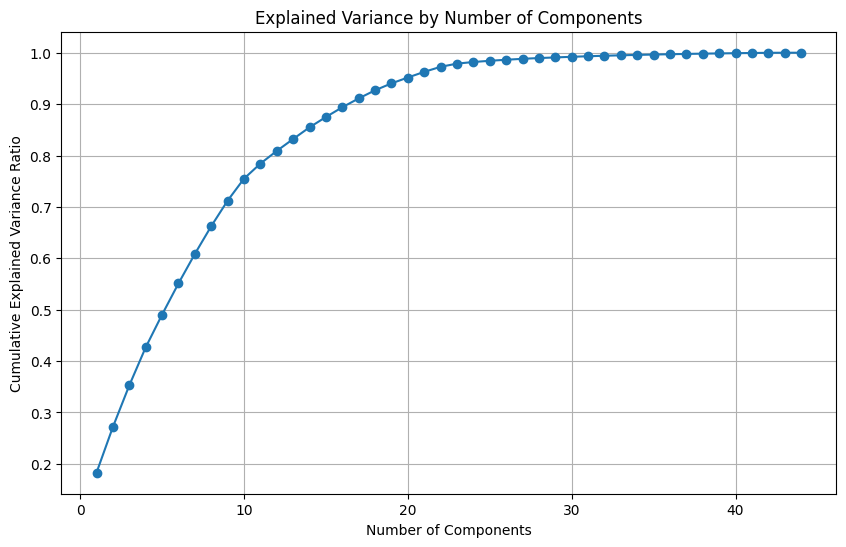

In [ ]:
pca = PCA(n_components=min(X_scaled_df.shape))
components = pca.fit_transform(X_scaled_df)

explained_var_ratio = pca.explained_variance_ratio_
cumulative_explained_var = explained_var_ratio.cumsum()
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_var)+1), cumulative_explained_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance by Number of Components')
plt.grid(True)
plt.show()

In [ ]:
# Устанавливаем нужное количество компонентов
final_pca = PCA(n_components=20)
reduced_data = final_pca.fit_transform(X_scaled_df)

# Возвращаемся к dataframe с первоначальными индексами
reduced_df = pd.DataFrame(reduced_data, index=X_scaled_df.index, columns=X_scaled_df.columns[:final_pca.n_components])

In [ ]:
reduced_df.columns

Index(['tree_depth_mean', 'tree_depth_median', 'tree_depth_max',
       'tree_depth_std', 'dep_distance_mean', 'dep_distance_median',
       'dep_distance_max', 'dep_distance_std', 'clauses_mean',
       'clauses_median', 'clauses_max', 'clauses_std', 'amod_chain_mean',
       'amod_chain_median', 'amod_chain_max', 'amod_chain_std', 'advcl_mean',
       'advcl_median', 'advcl_max', 'advcl_std'],
      dtype='object')

## Иерархическая кластеризация

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

## Метод Ward

Разделим данные с помощью метода Ward и построим дендрограму.

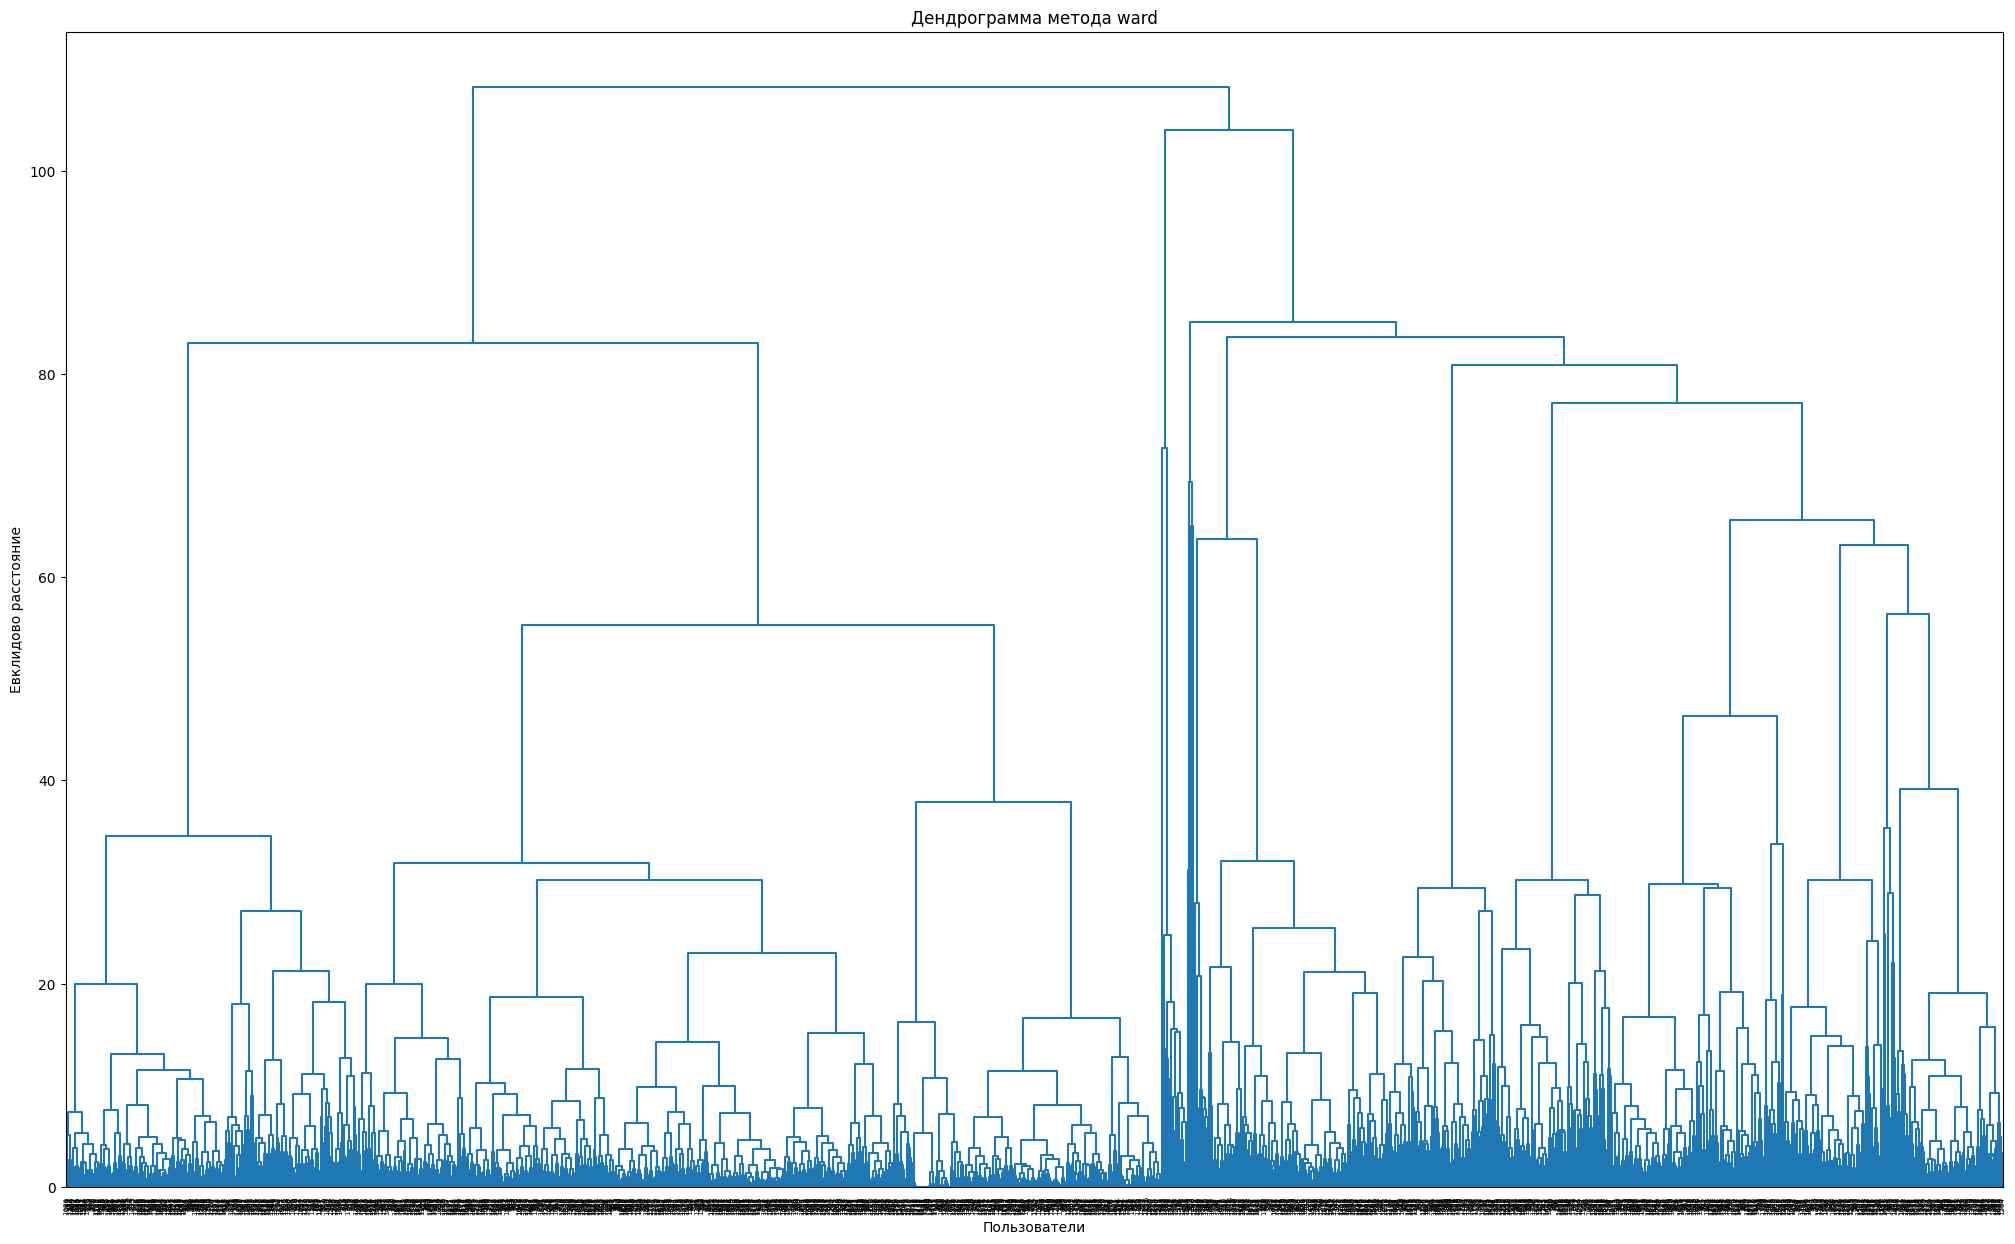

In [ ]:
WARD = linkage(reduced_df, method="ward")

plt.figure(figsize=(25, 15))
dendrogram(WARD, color_threshold=0)
plt.title('Дендрограмма метода ward')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
df_copy = reduced_df.copy()

### Визуальное разделение

Попробуем разделить данные на кластеры визуально по дендрограме. Объекты должны сгруппироваться таким образом, чтобы минимизировать различия внутри кластеров и максимизировать различия между разными кластерами. Выберем порог 35, так как он кажется более оптимальным при неравномерном распределении наблюдений.

In [ ]:
users_res = fcluster(WARD, t = 35, criterion='distance')
users_copy['ward_by_eye'] = users_res

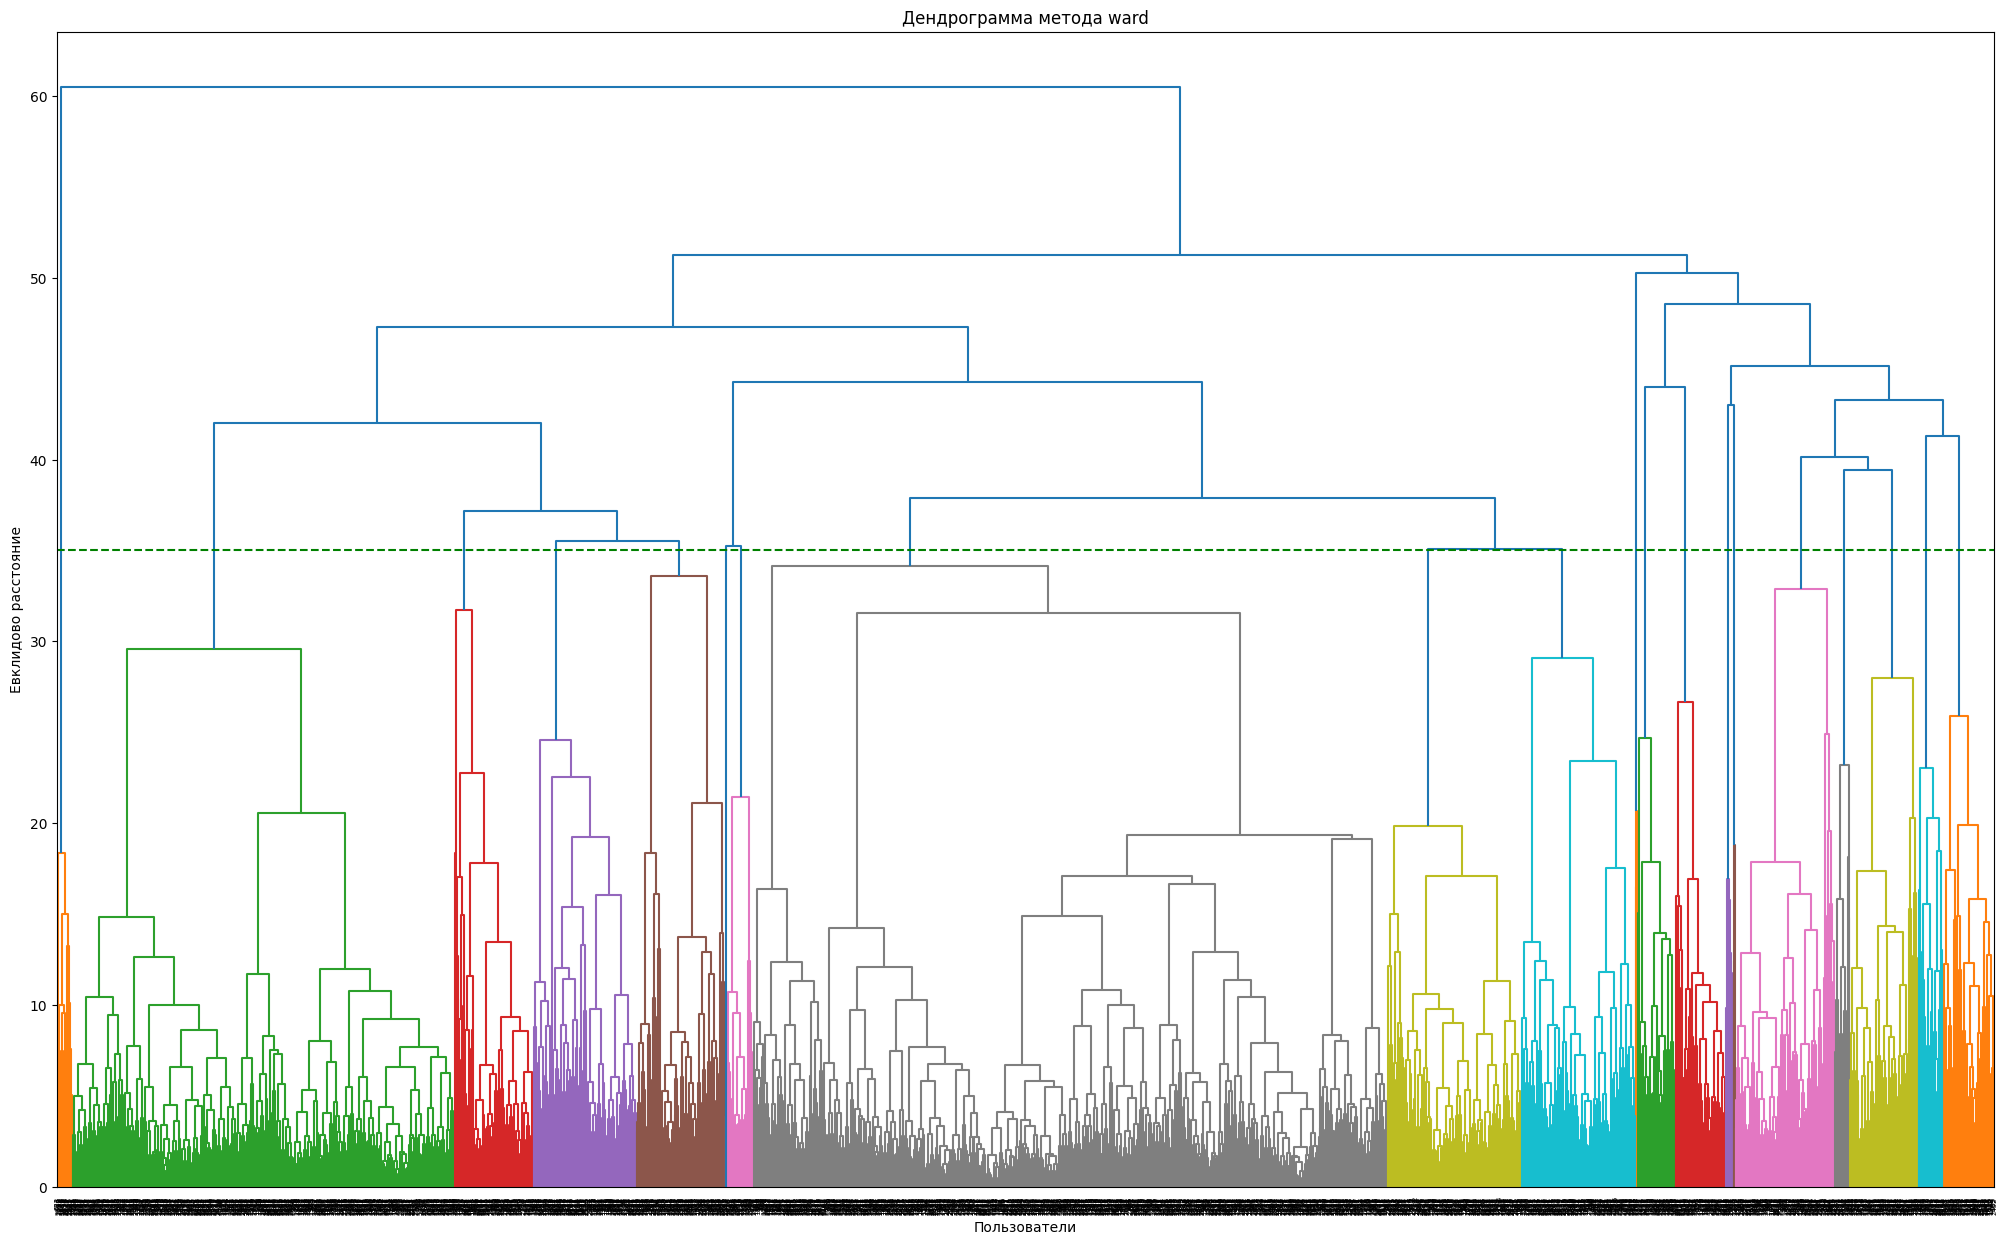

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(WARD, color_threshold=35)
plt.axhline(y=35, color='green', linestyle='--')
plt.title('Дендрограмма метода ward')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
print(users_copy['ward_by_eye'].value_counts())
print(len(users_copy['ward_by_eye'].value_counts().index))

ward_by_eye
8     981
2     592
9     208
10    176
4     159
16    154
5     138
3     122
18    106
20     80
13     78
12     58
6      43
19     38
1      24
17     23
14     12
11      4
15      3
7       1
Name: count, dtype: int64
20


Наблюдения были поделены на 20 кластеров, при этом кластеризация произвелась неодинаково. В одном кластере мы видим больше 900 наблюдений, а в другом всего одно. Посмотрим на оценку силуэта.

In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['ward_by_eye'])
print(silhouette_avg)

silhouette_avg = silhouette_score(scaled_df, users_copy['ward_by_eye'])
new_row = {
    'method': 'ward_by_eye',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 20,
    'threshold': 35
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

0.004319069867189872


<ipython-input-61-d47de5b7d97e>:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)


,method,silhouette_avg,number_of_clusters,threshold
0,ward_by_eye,0.00432,20,35


Значение силуэта почти равно нулю, следовательно, такие параметры плохо справляются с кластеризацией.

### Метод локтя

Воспользуемся методом локтя, чтобы определить оптимальное количество кластеров.

In [ ]:
def plot_elbow(Z, h=10, w=5):
    plt.figure(figsize=(h, w))
    plt.plot(np.array(range(1, np.shape(Z)[0]+1)),
             Z[:,2][::-1],
             marker='o')
    plt.xticks(np.arange(0, len(Z), step=25))
    plt.xlabel("Number of clusters")
    plt.ylabel("Merge distance")
    plt.show()

Находем точку излома («локоть») на графике, которая указывает на оптимальное число кластеров.

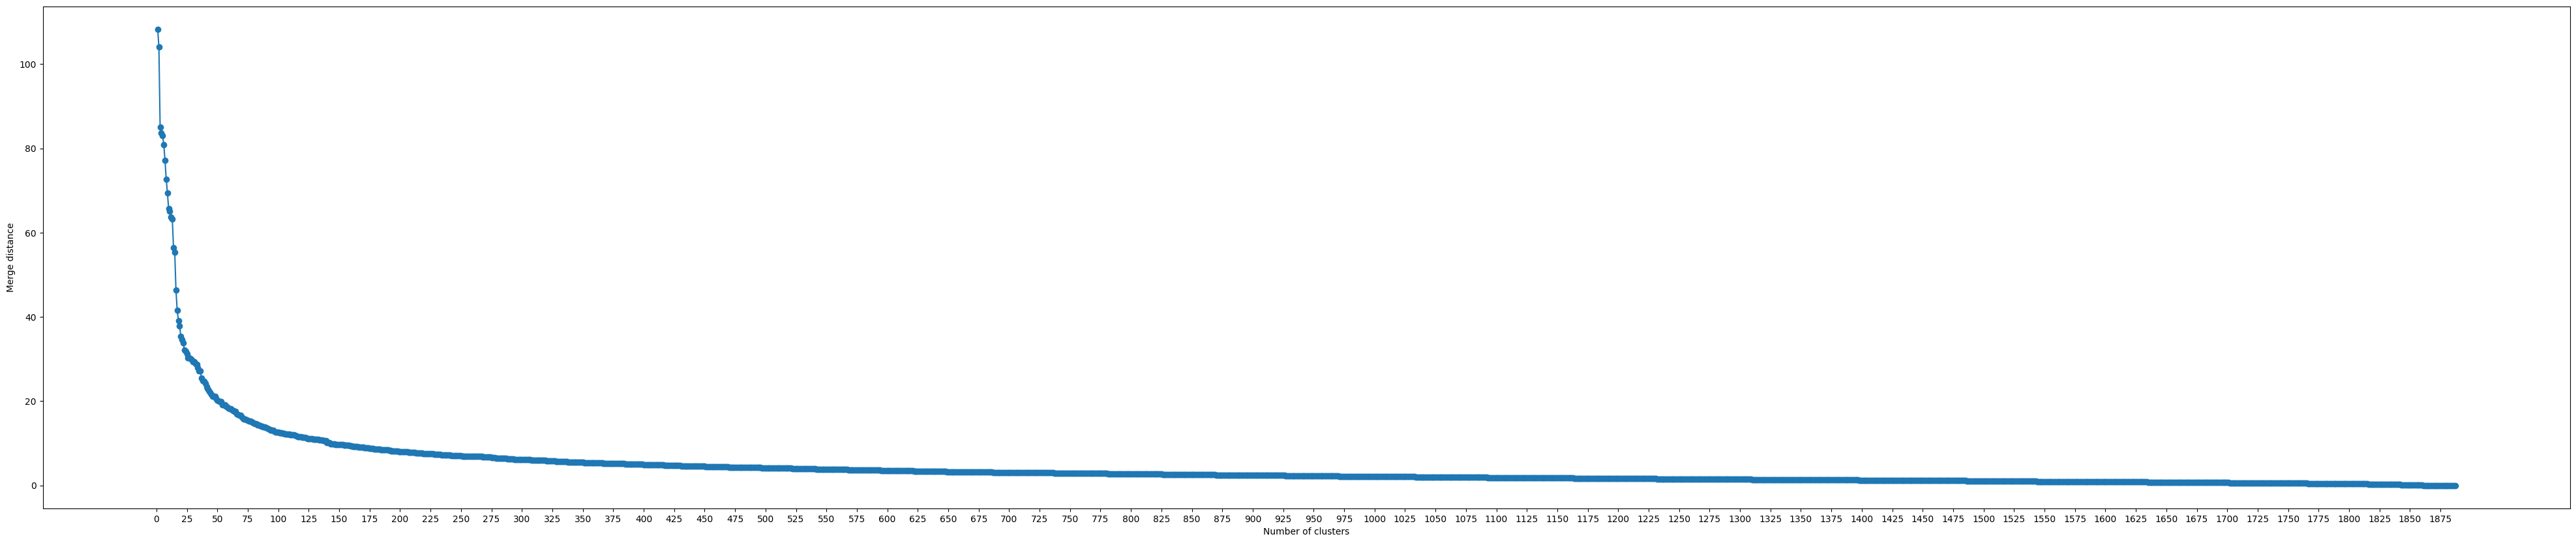

In [ ]:
plot_elbow(WARD, h=50, w=10)

Оптимальным будет значение 100, при котором ошибка перестаёт существенно уменьшаться, то есть начинает сглаживаться.

In [ ]:
df_res = fcluster(WARD, t = 100, criterion='maxclust')
df_copy['ward_by_elbow'] = df_res

Попробуем найти порог

In [ ]:
clusters = fcluster(WARD, t = 13.9, criterion='distance')
len(set(clusters))

88

Данные можно примерно поделить почти на 100 кластеров, если установить порог 88

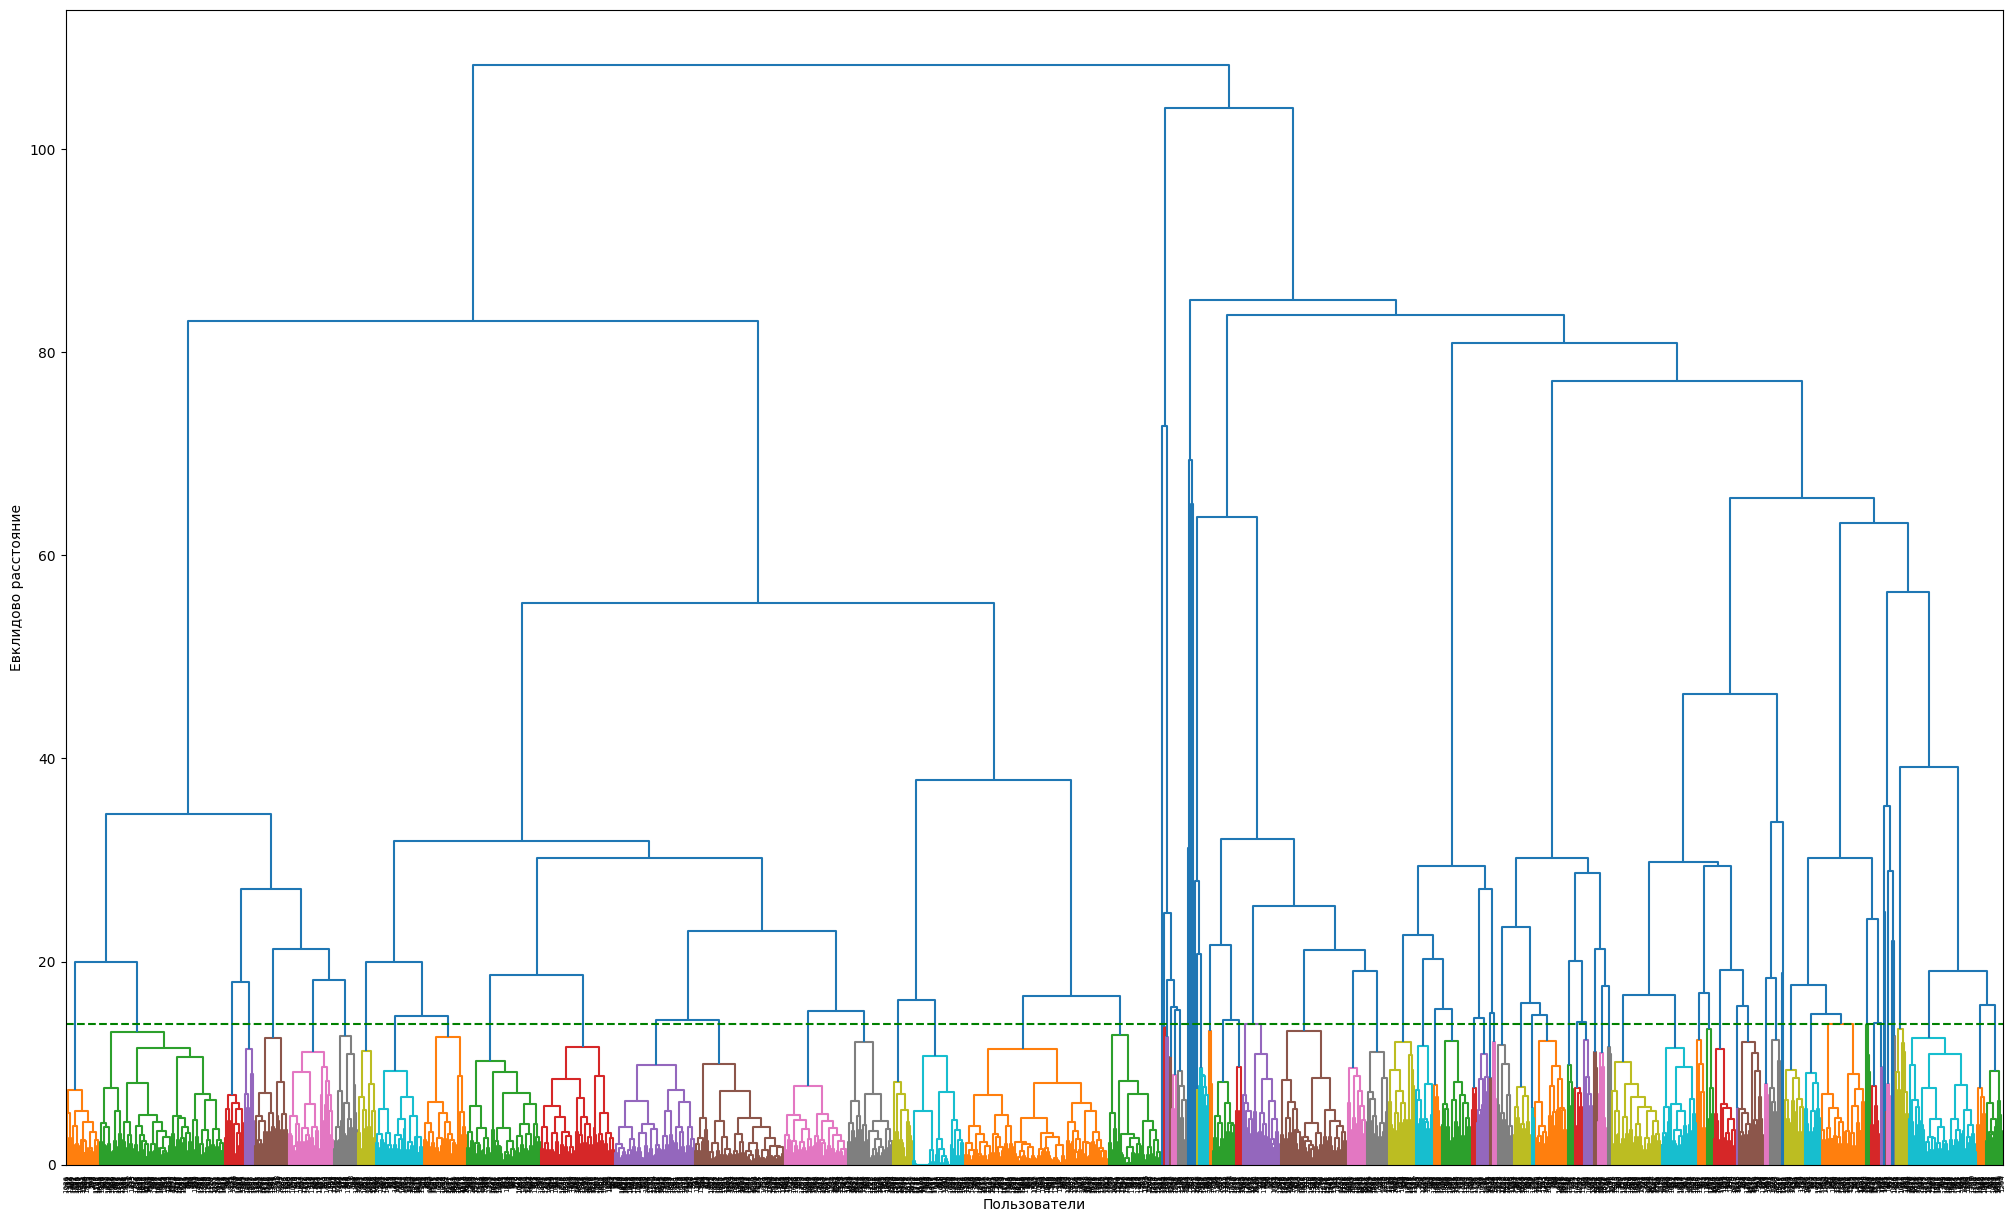

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(WARD, color_threshold=13.9)
plt.axhline(y=13.9, color='green', linestyle='--')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
print(df_copy['ward_by_elbow'].value_counts())
print(len(df_copy['ward_by_elbow'].value_counts().index))

ward_by_elbow
21    141
3     100
16     87
15     78
13     72
     ... 
80      1
86      1
40      1
32      1
93      1
Name: count, Length: 100, dtype: int64
100


 Данные разделены более равномерно, но все еще есть кластеры, которые состоят из одного объекта.

In [ ]:
silhouette_avg = silhouette_score(reduced_df, df_copy['ward_by_elbow'])
print(silhouette_avg)

silhouette_avg = silhouette_score(reduced_df, df_copy['ward_by_elbow'])
new_row = {
    'method': 'ward_by_elbow',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 100,
    'threshold': 88
}

new_row

0.1252193674310255


{'method': 'ward_by_elbow',
 'silhouette_avg': 0.12522,
 'number_of_clusters': 100,
 'threshold': 88}

Коэффициест силуэта близок к нулю, что говорит о плохой кластеризации.

### Автоматический механизм

Сформируем кластеры автоматическим механизмом, который выбирает количество кластеров на основе указанного критерия (в данном случае — коэффициента максимальной согласованности).

In [ ]:
from scipy.cluster.hierarchy import inconsistent
from scipy.cluster.hierarchy import fcluster, maxinconsts

R = inconsistent(WARD, d=12) # d - глубина анализа (количество предыдущих шагов для оценки показателей)
MI = maxinconsts(WARD, R)

In [ ]:
users_res = fcluster(WARD, t=20, criterion='maxclust_monocrit', monocrit=MI)
df_copy['ward_maxclust_monocrit'] = users_res

In [ ]:
print(df_copy['ward_maxclust_monocrit'].value_counts())
print(len(df_copy['ward_maxclust_monocrit'].value_counts().index))

ward_maxclust_monocrit
14    382
1     284
7     193
11    175
4     165
3     144
13    111
2     107
12    106
5     106
6      69
8      25
10     14
9       7
Name: count, dtype: int64
14


С критерием 'maxclust_monocrit' данные были поделены на 14 кластеров. Разбиение более сбалансировано среди кластеров, но надо посмотреть на коэффициент силуэта.

Попробуем найти, при каком пороге данные будут разделены на 14 кластеров.

In [ ]:
clusters = fcluster(WARD, t = 60, criterion='distance')
len(set(clusters))

14

Данные можно поделить на 14 кластеров, если установить порог 60.

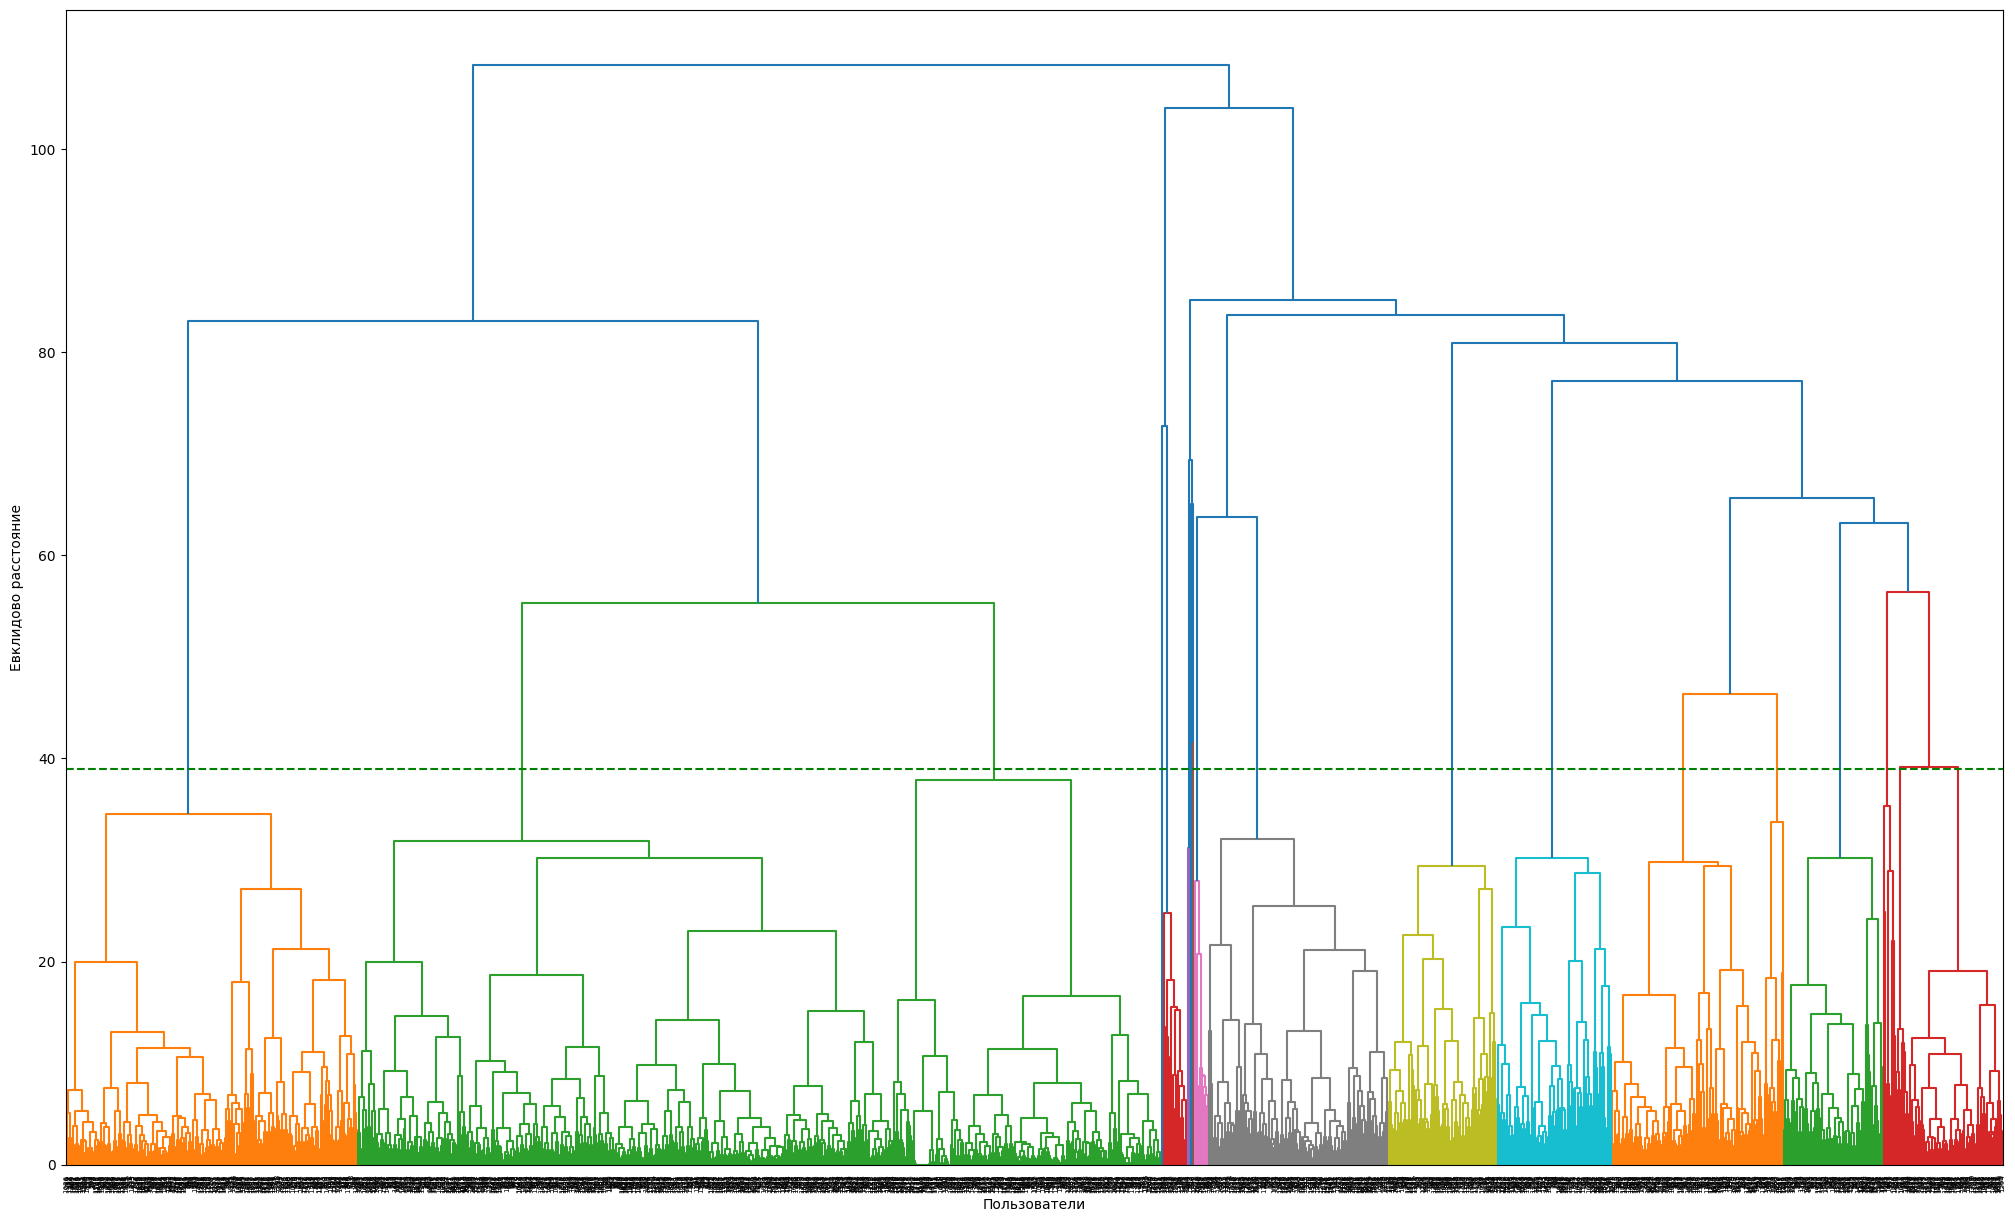

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(WARD, color_threshold=60)
plt.axhline(y=39, color='green', linestyle='--')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
silhouette_avg = silhouette_score(reduced_df, df_copy['ward_maxclust_monocrit'])
print(silhouette_avg)

silhouette_avg = silhouette_score(reduced_df, df_copy['ward_maxclust_monocrit'])
new_row = {
    'method': 'ward_maxclust_monocrit',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 14,
    'threshold': 60
}

new_row

0.026944628978823063


{'method': 'ward_maxclust_monocrit',
 'silhouette_avg': 0.02694,
 'number_of_clusters': 14,
 'threshold': 60}

Оценка силуэта близка к нулю в этом случае, то есть кластеризация данных неуспешна.

**Вывод:** метод WARD с евклидовым расстоянием и различными критериями разбиения на кластеры плохо справляется с этой задачей.

## Метод complete  

Попробуем метод полной связи и манхэттенское расстояние.

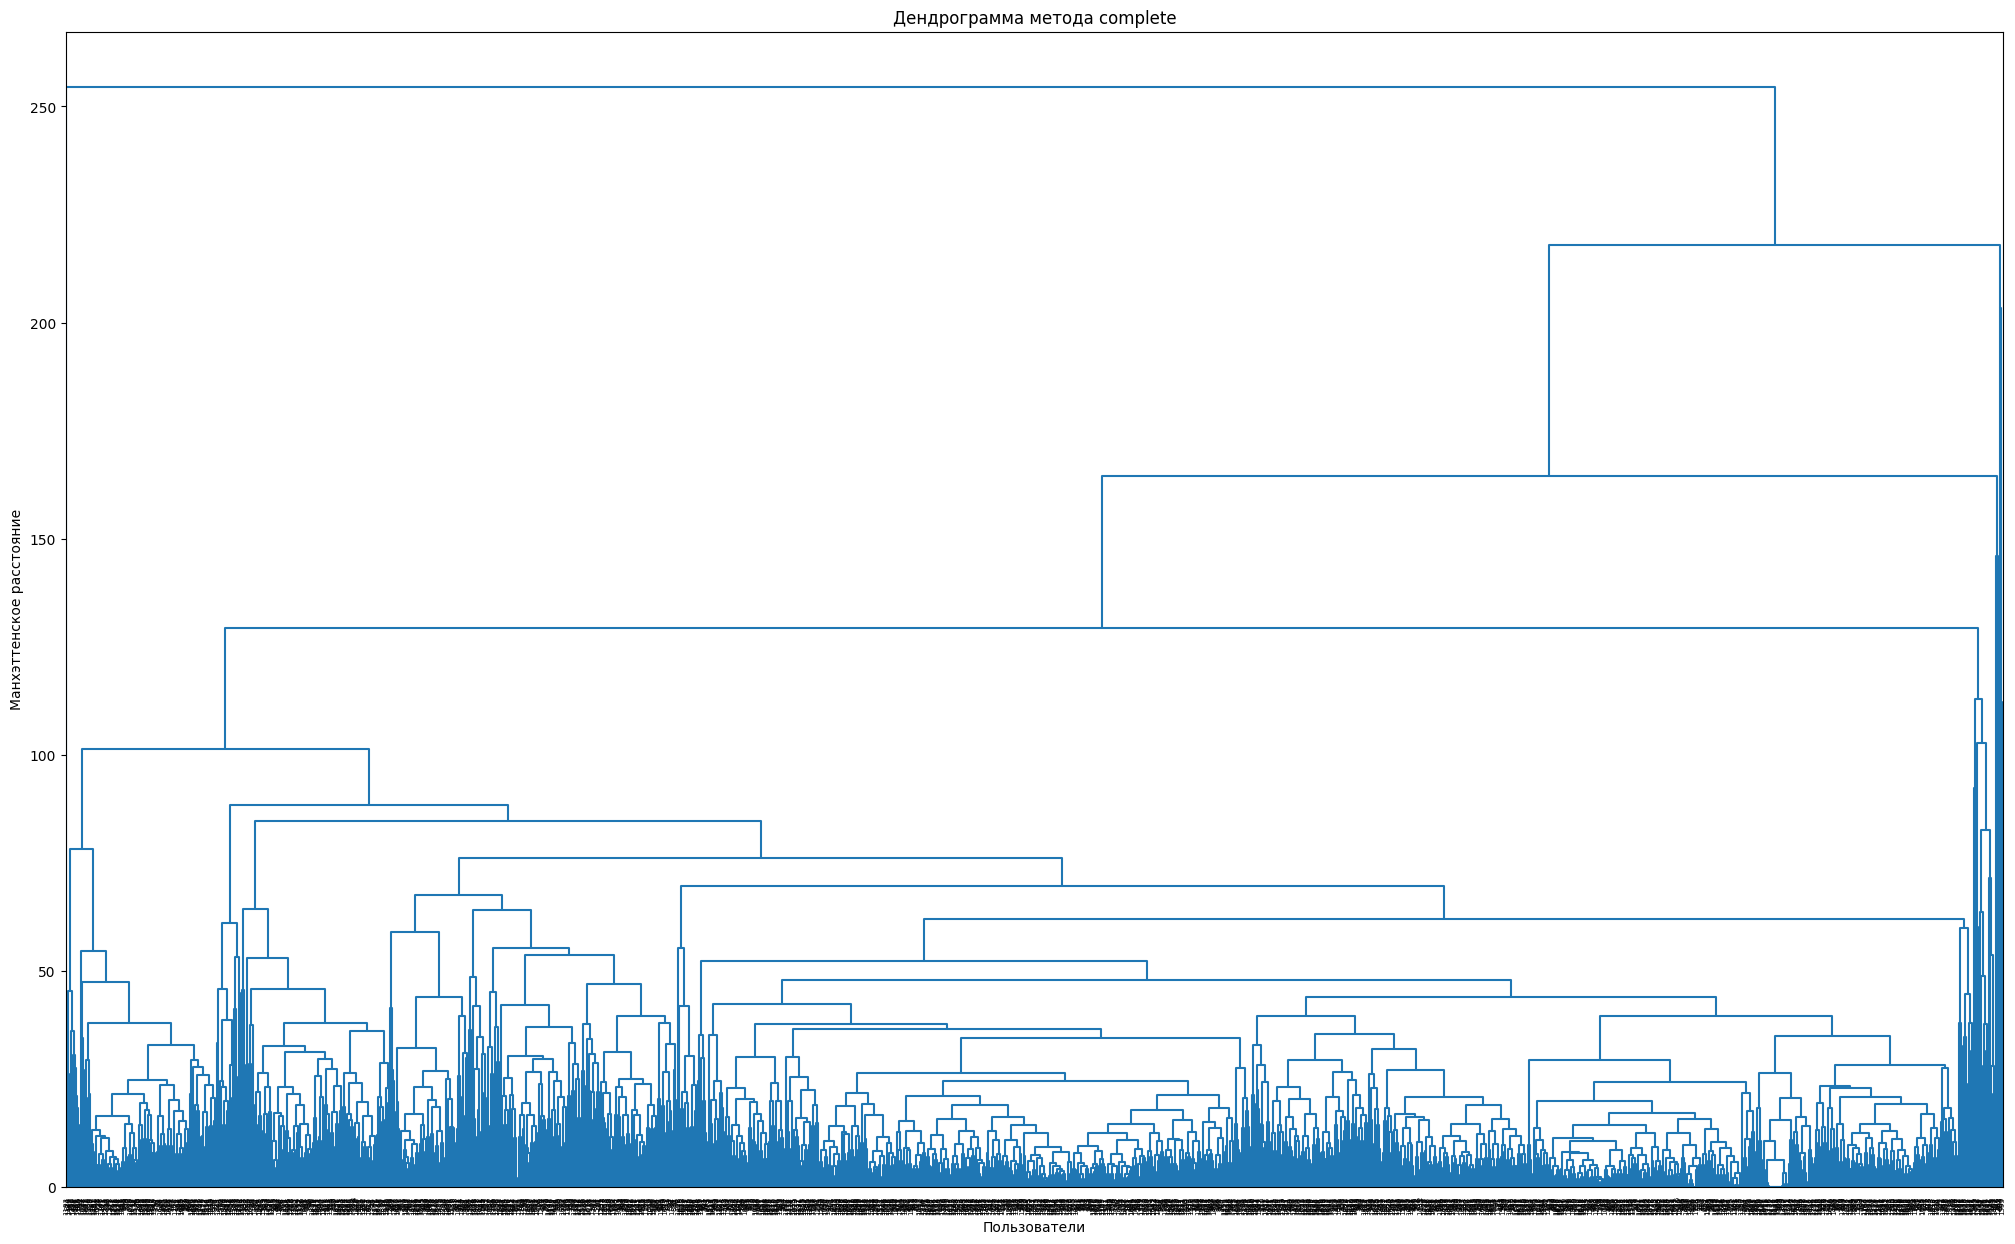

In [ ]:
Complete = linkage(reduced_df, method='complete', metric='cityblock')

plt.figure(figsize=(25, 15))
dendrogram(Complete, color_threshold=0)
plt.title('Дендрограмма метода complete')
plt.xlabel('Пользователи')
plt.ylabel('Манхэттенское расстояние')
plt.show()

### Визуальное разделение

Попробуем разделить данные на кластеры визуально по дендрограме. Оптимальным кажется порог 30. Так различия внутри кластеров будут менее заметны.

In [ ]:
df_res = fcluster(Complete, t = 30, criterion='distance')
users_copy['complete_by_eye'] = users_res

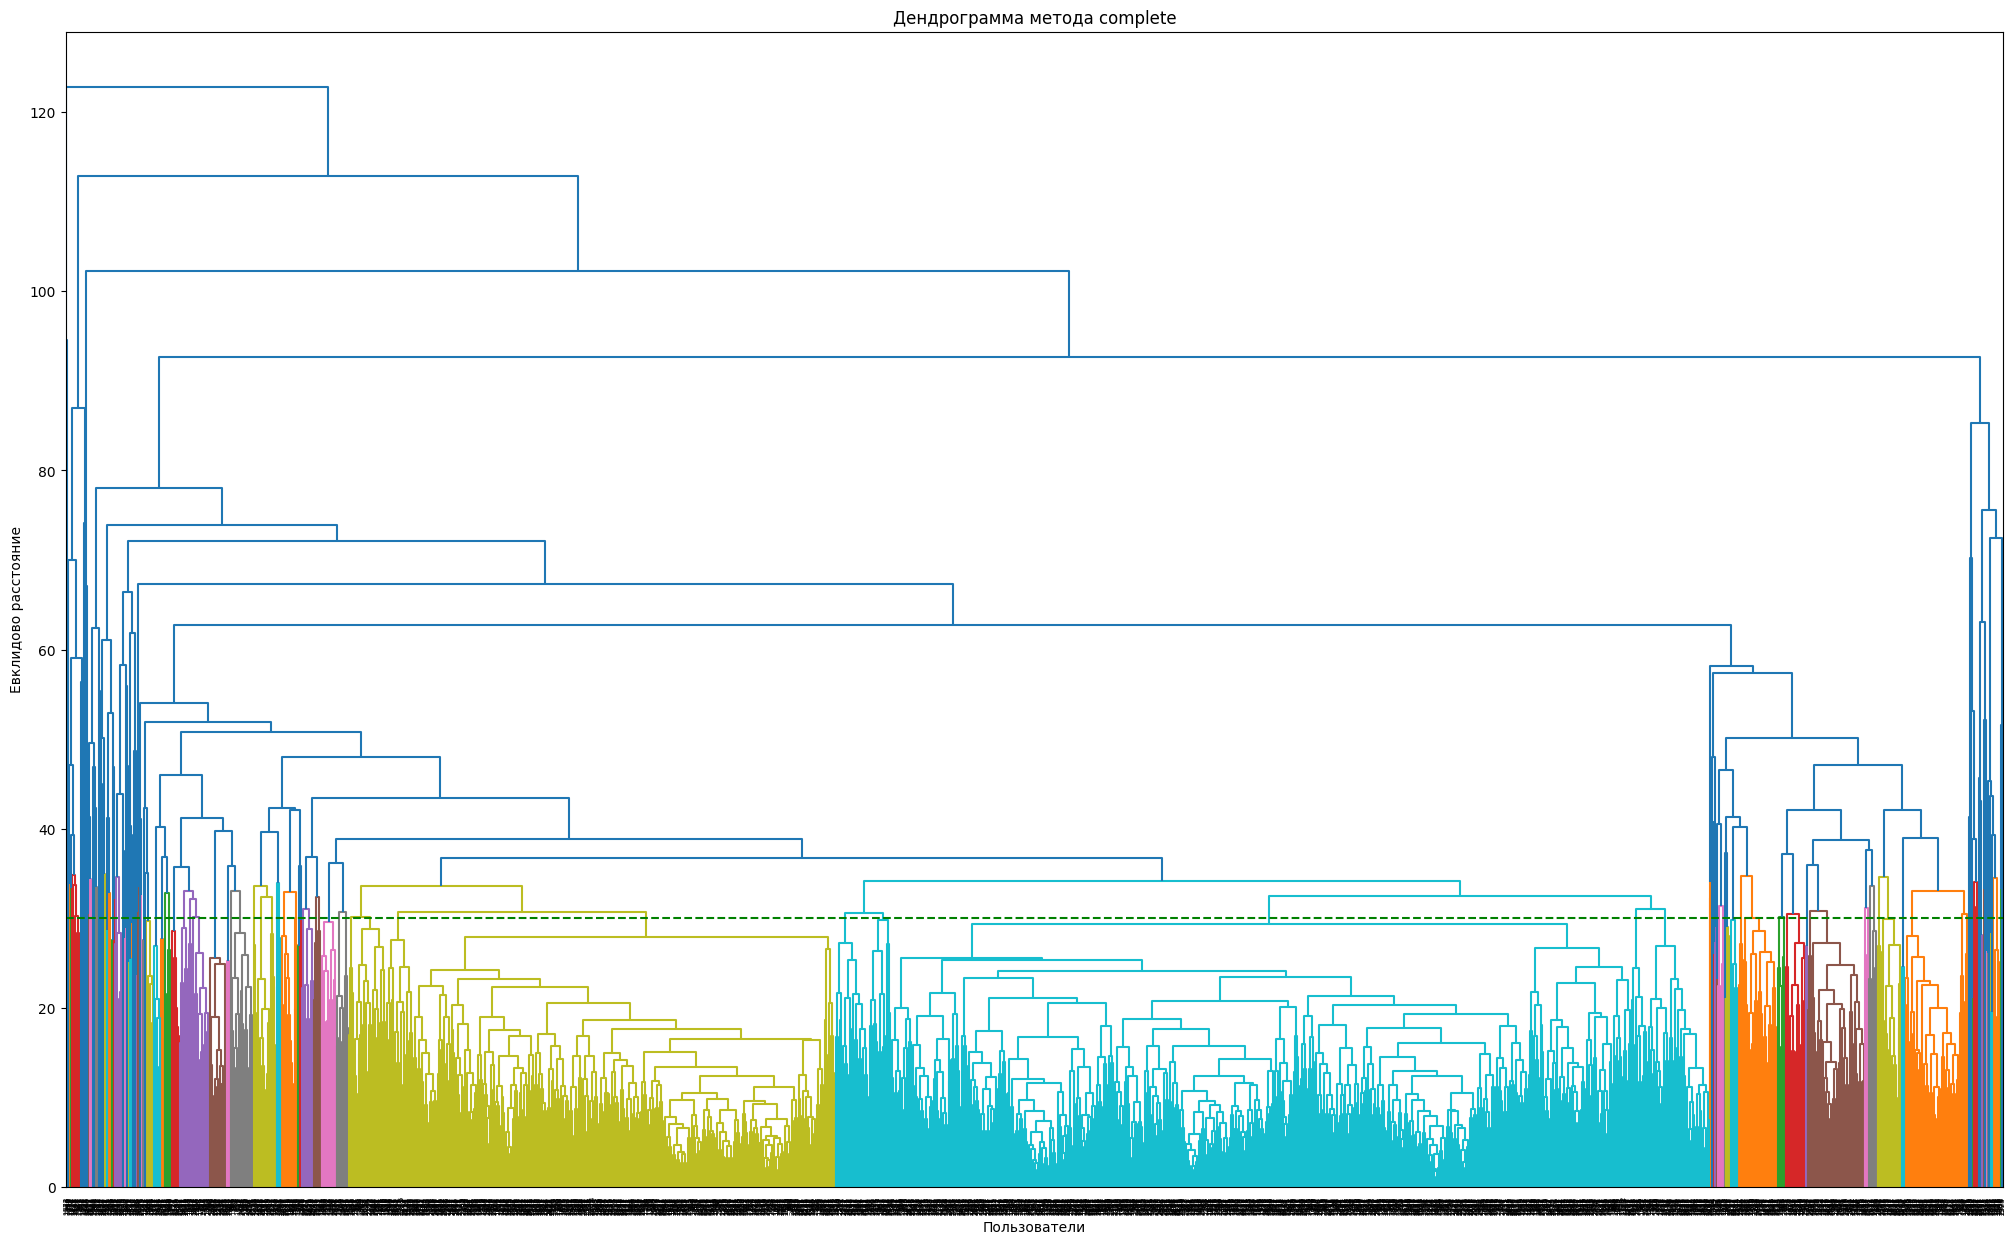

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(Complete, color_threshold=35)
plt.axhline(y=30, color='green', linestyle='--')
plt.title('Дендрограмма метода complete')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
print(users_copy['complete_by_eye'].value_counts())
print(len(users_copy['complete_by_eye'].value_counts().index))

complete_by_eye
106    1148
103     654
108      95
138      85
130      81
       ... 
110       1
152       1
166       1
32        1
2         1
Name: count, Length: 166, dtype: int64
166


Наблюдения были поделены на 166 кластеров, при этом кластеризация произвелась неравномерно. В одном кластере мы видим больше 1100 наблюдений, а в других всего одно. Посмотрим на оценку силуэта.

In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['complete_by_eye'])
print(silhouette_avg)

silhouette_avg = silhouette_score(scaled_df, users_copy['complete_by_eye'])
new_row = {
    'method': 'complete_by_eye',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 166,
    'threshold': 30
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

0.028270190376853455


,method,silhouette_avg,number_of_clusters,threshold
0,ward_by_eye,0.00432,20,35
1,ward_by_elbow,-0.01818,100,13.9
2,ward_maxclust_monocrit,-0.12225,15,39
3,complete_by_eye,0.02827,166,30


Значение силуэта почти равно нулю, следовательно, такие параметры плохо справляются с кластеризацией.

### Метод локтя

Воспользуемся методом локтя, чтобы определить оптимальное количество кластеров.

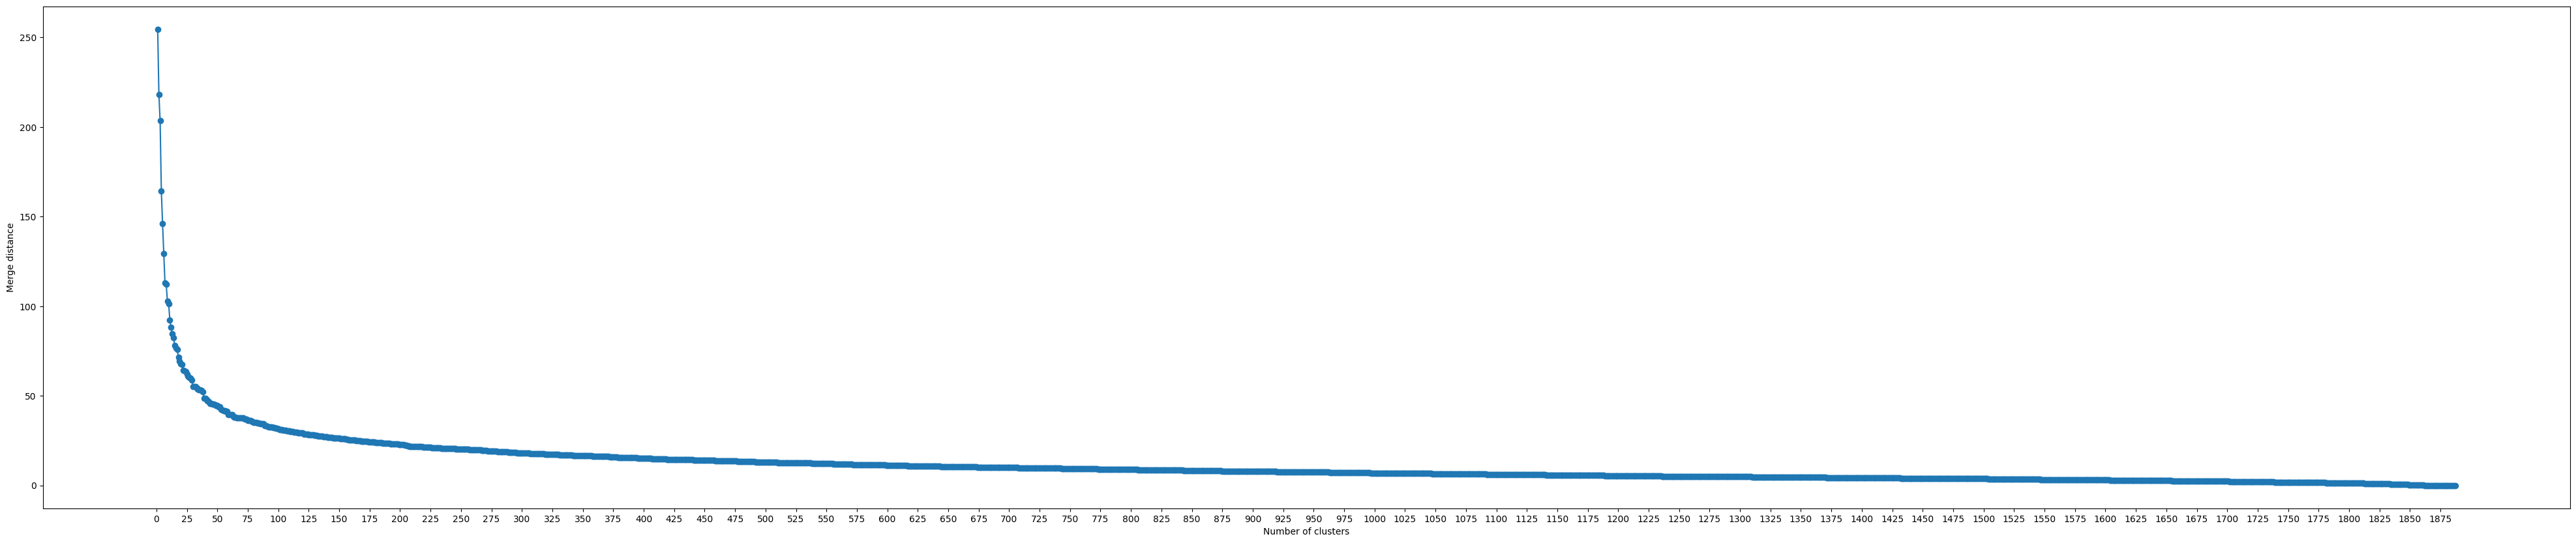

In [ ]:
plot_elbow(Complete, h=50, w=10)

Oптимальным будет значение 25.

In [ ]:
res = fcluster(Complete, t = 25, criterion='maxclust')
df_copy['complete_by_elbow'] = res

Попробуем найти порог разбиения на кластеры.

In [ ]:
clusters = fcluster(Complete, t = 63, criterion='distance')
len(set(clusters))

25

Данные можно поделить почти на 25 кластеров, если установить порог 63.

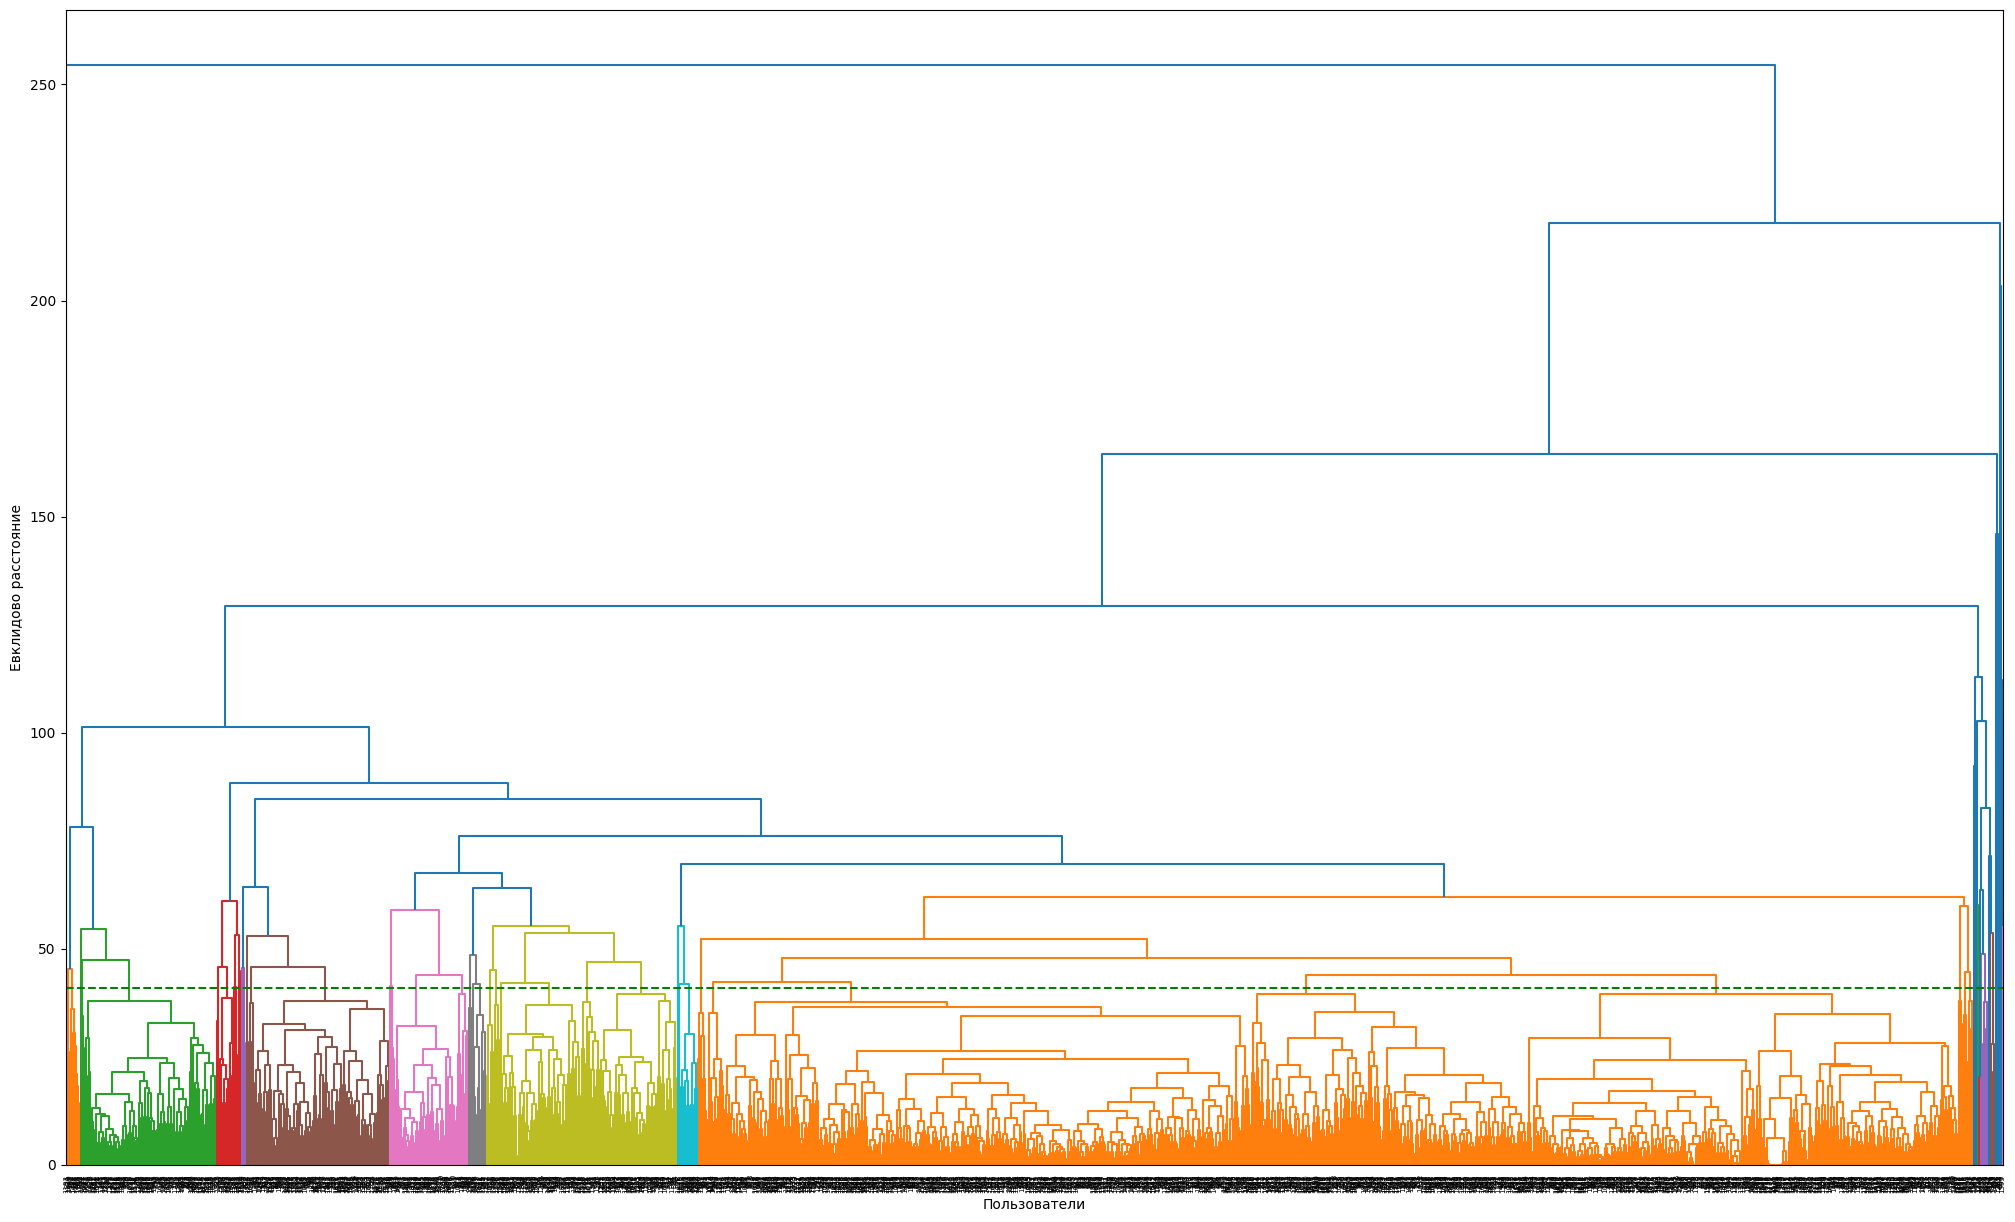

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(Complete, color_threshold=63)
plt.axhline(y=41, color='green', linestyle='--')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
print(df_copy['complete_by_elbow'].value_counts())
print(len(df_copy['complete_by_elbow'].value_counts().index))

complete_by_elbow
10    1243
8      186
5      140
2      133
6       77
3       24
9       20
7       17
1       13
16       8
17       6
4        5
22       2
15       2
14       2
21       1
11       1
23       1
24       1
19       1
12       1
25       1
20       1
18       1
13       1
Name: count, dtype: int64
25


Если мы делим в таком подходе данные на 75 кластеров, то в одном кластере оказывается больше тысячи наблюдений, а нескольких только одно.

In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['complete_by_elbow'])
print(silhouette_avg)

silhouette_avg = silhouette_score(scaled_df, users_copy['complete_by_elbow'])
new_row = {
    'method': 'complete_by_elbow',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 75,
    'threshold': 41
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

0.14016324239463349


,method,silhouette_avg,number_of_clusters,threshold
0,ward_by_eye,0.00432,20,35
1,ward_by_elbow,-0.01818,100,13.9
2,ward_maxclust_monocrit,-0.12225,15,39
3,complete_by_eye,0.02827,166,30
4,complete_by_elbow,0.14016,75,41


Коэффициент силуэта близок нулю, но уже выше чем в прошлых методах.

### Автоматический механизм

In [ ]:
from scipy.cluster.hierarchy import inconsistent
from scipy.cluster.hierarchy import fcluster, maxinconsts

R = inconsistent(Complete, d=30) # d - глубина анализа (количество предыдущих шагов для оценки показателей)
MI = maxinconsts(Complete, R)

In [ ]:
res = fcluster(Complete, t=50, criterion='maxclust_monocrit', monocrit=MI)
df_copy['complete_maxclust_monocrit'] = res

In [ ]:
print(df_copy['complete_maxclust_monocrit'].value_counts())
print(len(df_copy['complete_maxclust_monocrit'].value_counts().index))

complete_maxclust_monocrit
7     280
17    269
22    197
20    188
14    171
15    158
6     140
2     132
13     76
11     59
12     33
4      24
24     22
8      20
16     16
10     16
19     15
23     15
21     14
1      13
9      10
18      6
5       5
26      4
25      3
3       1
27      1
Name: count, dtype: int64
27


Попробуем найти, при каком пороге данные будут разделены на 27 кластера.

In [ ]:
clusters = fcluster(Complete, t = 61, criterion='distance')
len(set(clusters))

27

Данные можно примерно поделить на кластеров, если установить порог 100.

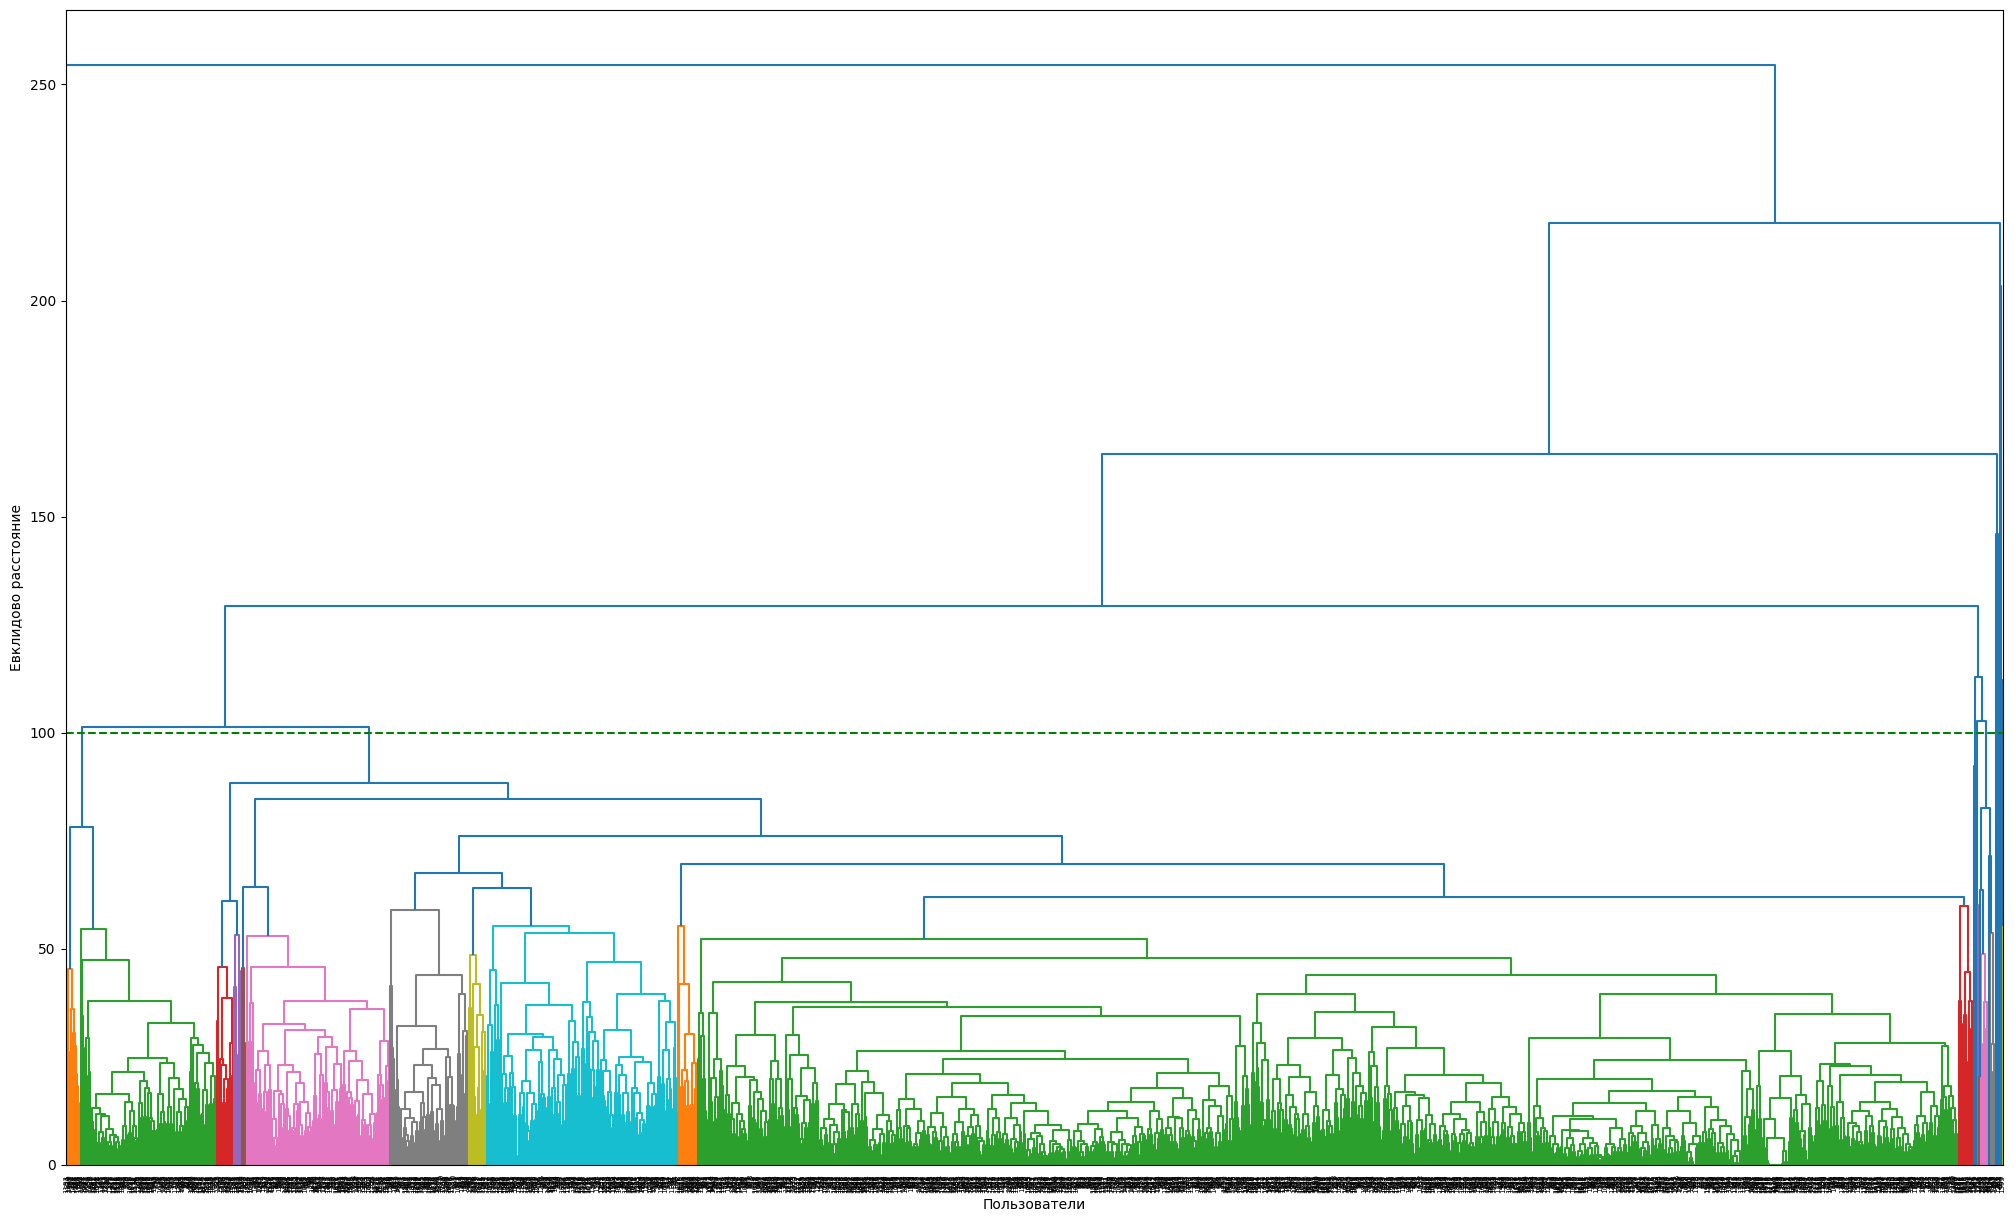

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(Complete, color_threshold=61)
plt.axhline(y=100, color='green', linestyle='--')
plt.xlabel('Пользователи')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
silhouette_avg = silhouette_score(reduced_df, df_copy['complete_maxclust_monocrit'])
print(silhouette_avg)

-0.004902488369174859


In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['complete_maxclust_monocrit'])
print(silhouette_avg)

silhouette_avg = silhouette_score(scaled_df, users_copy['complete_maxclust_monocrit'])
new_row = {
    'method': 'complete_maxclust_monocrit',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 4,
    'threshold': 100
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

0.5023701788771711


,method,silhouette_avg,number_of_clusters,threshold
0,ward_by_eye,0.00432,20,35
1,ward_by_elbow,-0.01818,100,13.9
2,ward_maxclust_monocrit,-0.12225,15,39
3,complete_by_eye,0.02827,166,30
4,complete_by_elbow,0.14016,75,41
5,complete_maxclust_monocrit,0.50237,4,100


Критерий разбиения на кластеры 'maxclust_monocrit' имеет оценку силуэта выше, чем остальные. Возможно, разделение данных всего на несколько кластеров лучше объясняет, какие существуют типы пользователей в этом наборе данных.

**Вывод:** метод подной связи и манхэттенское расстояние справились с кластеризацией лучше, чем метод WARD и евклидово расстояние. Более высокую оценку получил критерий 'maxclust_monocrit'.

## Метод average

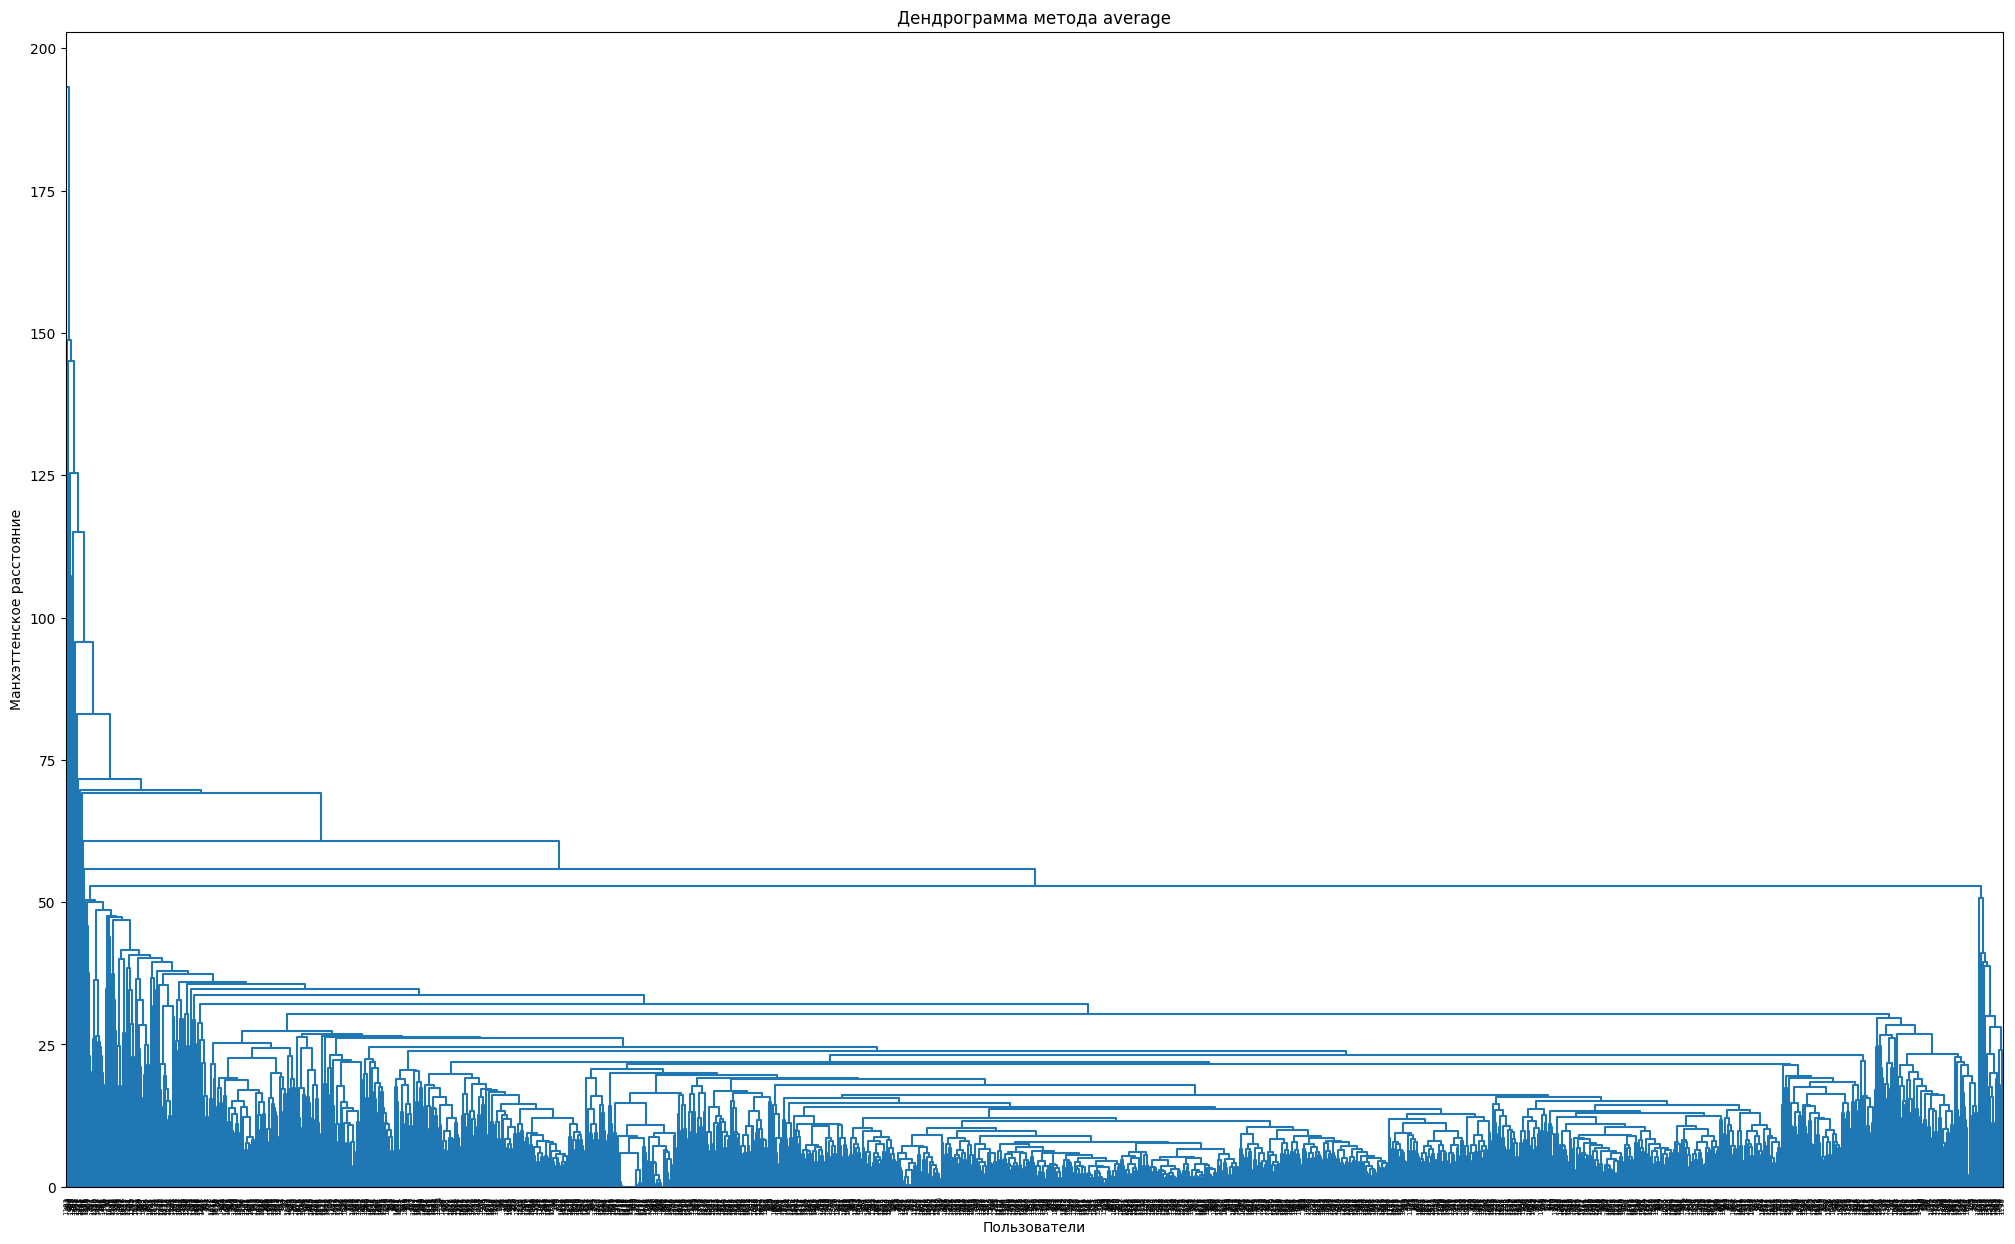

In [ ]:
Average = linkage(reduced_df, method='average', metric='cityblock')

plt.figure(figsize=(25, 15))
dendrogram(Average, color_threshold=0)
plt.title('Дендрограмма метода average')
plt.xlabel('Пользователи')
plt.ylabel('Манхэттенское расстояние')
plt.show()

### Визуальное разделение

Попробуем разделить данные на кластеры визуально по дендрограме. Оптимальным будет порог 30, так как именно на этом расстоянии происходит отрыв части объектов от общей массы.

In [ ]:
users_res = fcluster(Average, t = 30, criterion='distance')
users_copy['average_by_eye'] = users_res

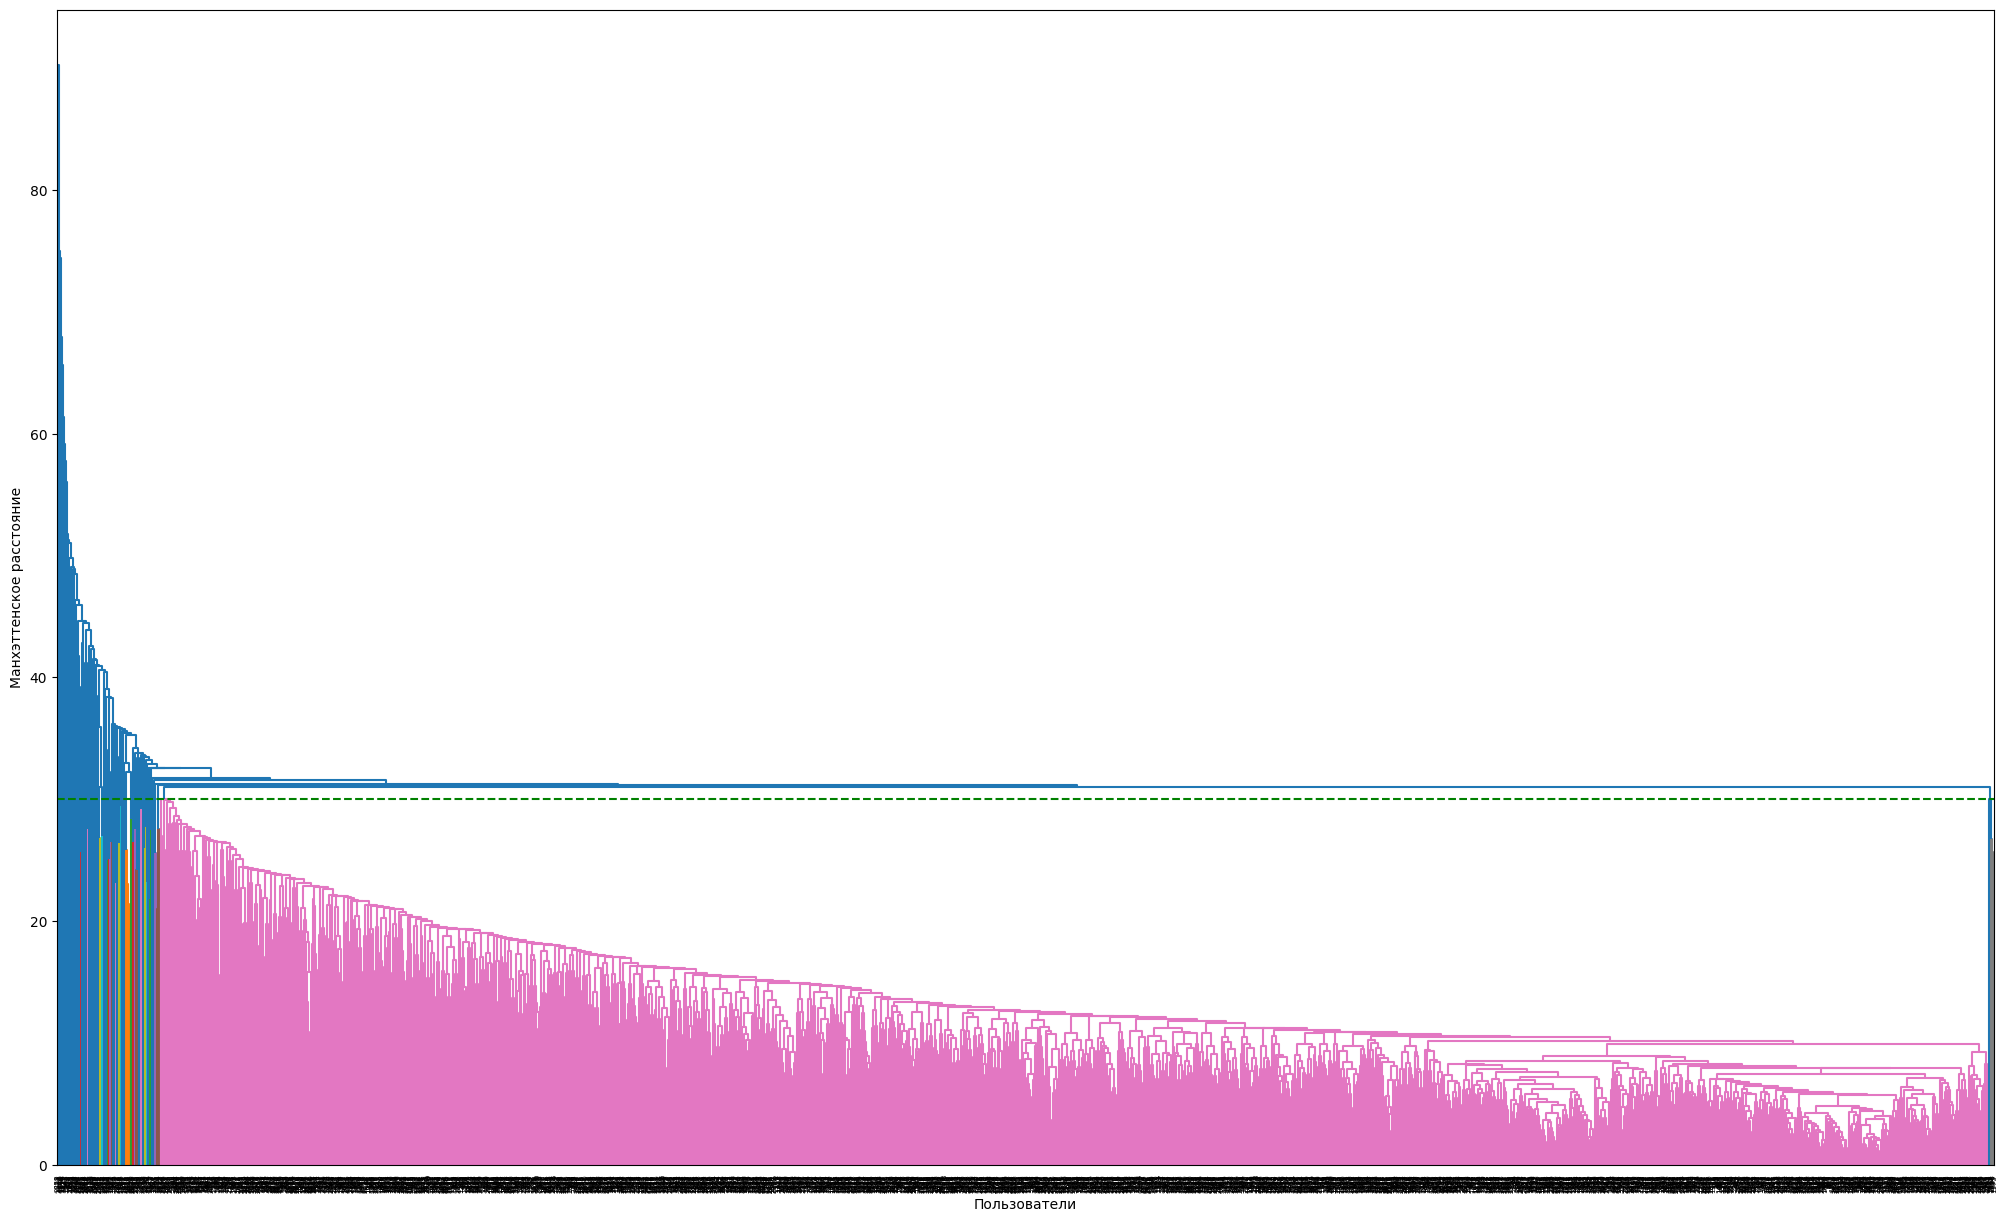

In [ ]:
plt.figure(figsize=(25, 15))
dendrogram(Average, color_threshold=30)
plt.axhline(y=30, color='green', linestyle='--')
plt.xlabel('Пользователи')
plt.ylabel('Манхэттенское расстояние')
plt.show()

In [ ]:
print(users_copy['average_by_eye'].value_counts())
print(len(users_copy['average_by_eye'].value_counts().index))

average_by_eye
84    2831
65      10
85       8
47       5
73       5
      ... 
43       1
25       1
18       1
29       1
2        1
Name: count, Length: 100, dtype: int64
100


Данные были поделены на 100 кластеров.

In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['average_by_eye'])
print(silhouette_avg)

silhouette_avg = silhouette_score(scaled_df, users_copy['average_by_eye'])
new_row = {
    'method': 'average_by_eye',
    'silhouette_avg': float(silhouette_avg.round(5)),
    'number_of_clusters': 100,
    'threshold': 30
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

0.36827429626698827


,method,silhouette_avg,number_of_clusters,threshold
0,ward_by_eye,0.00432,20,35
1,ward_by_elbow,-0.01818,100,13.9
2,ward_maxclust_monocrit,-0.12225,15,39
3,complete_by_eye,0.02827,166,30
4,complete_by_elbow,0.14016,75,41
5,complete_maxclust_monocrit,0.50237,4,100
6,average_by_eye,0.36827,100,30


Визуальное распределение уже получило оценку выше, чем все предыдущие способы классификации.

## Сomplete cosine

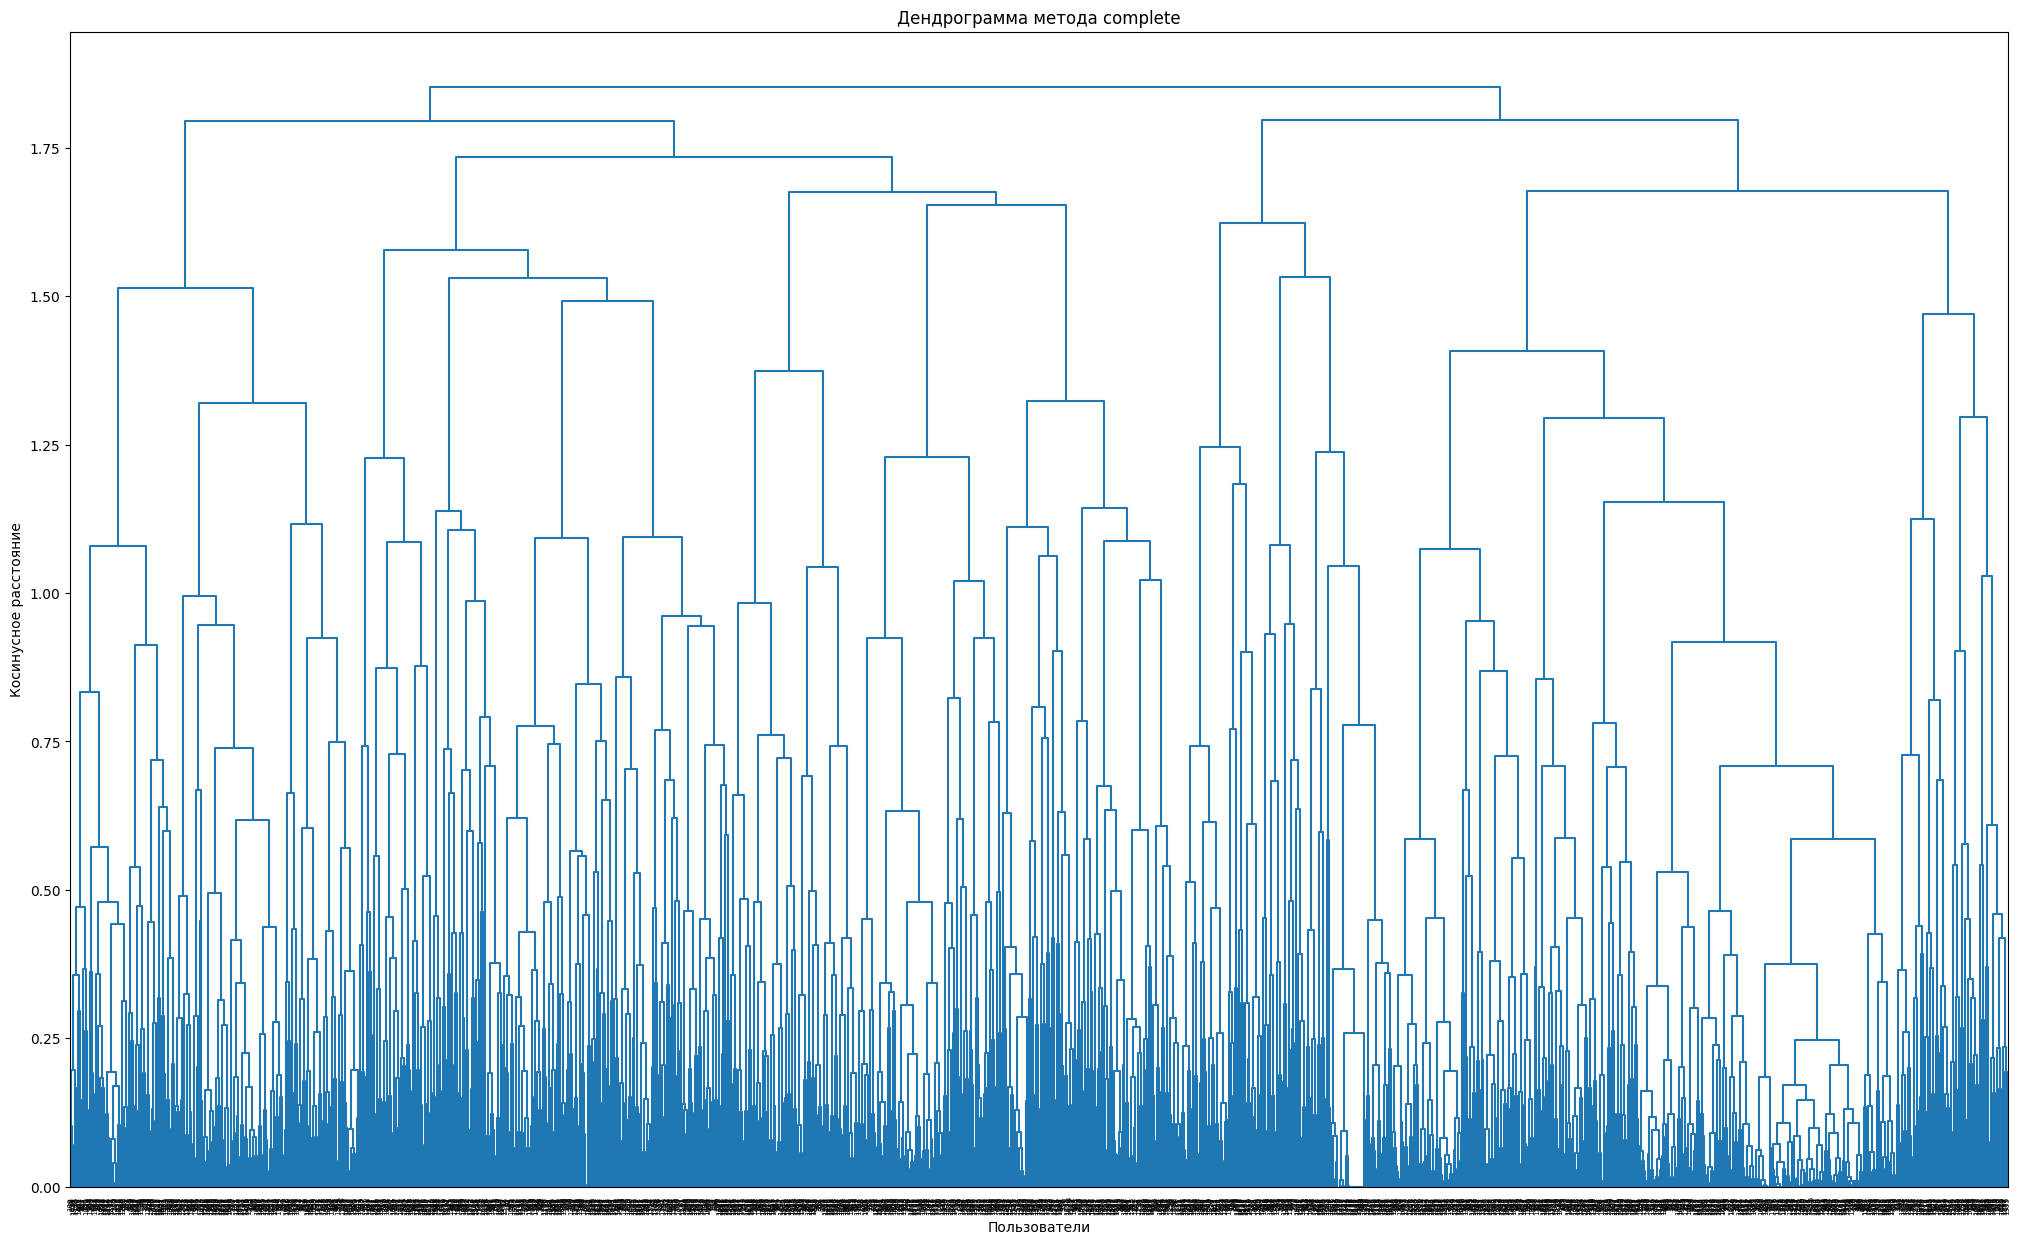

In [ ]:
Complete_cosine = linkage(reduced_df, method='complete', metric='cosine')
plt.figure(figsize=(25, 15))
dendrogram(Complete_cosine, color_threshold=0)
plt.title('Дендрограмма метода complete')
plt.xlabel('Пользователи')
plt.ylabel('Косинусное расстояние')
plt.show()

In [ ]:
res = fcluster(Complete_cosine, t = 1.54, criterion='distance')
df_copy['complete_cosine_by_eye'] = res

In [ ]:
silhouette_avg = silhouette_score(reduced_df, df_copy['complete_cosine_by_eye'])
float(silhouette_avg)

0.008461241454297315

In [ ]:
print(df_copy['complete_cosine_by_eye'].value_counts())
print(len(df_copy['complete_cosine_by_eye'].value_counts().index))

complete_cosine_by_eye
9     492
3     290
1     282
6     174
5     141
8     126
4     125
10    108
7      79
2      71
Name: count, dtype: int64
10


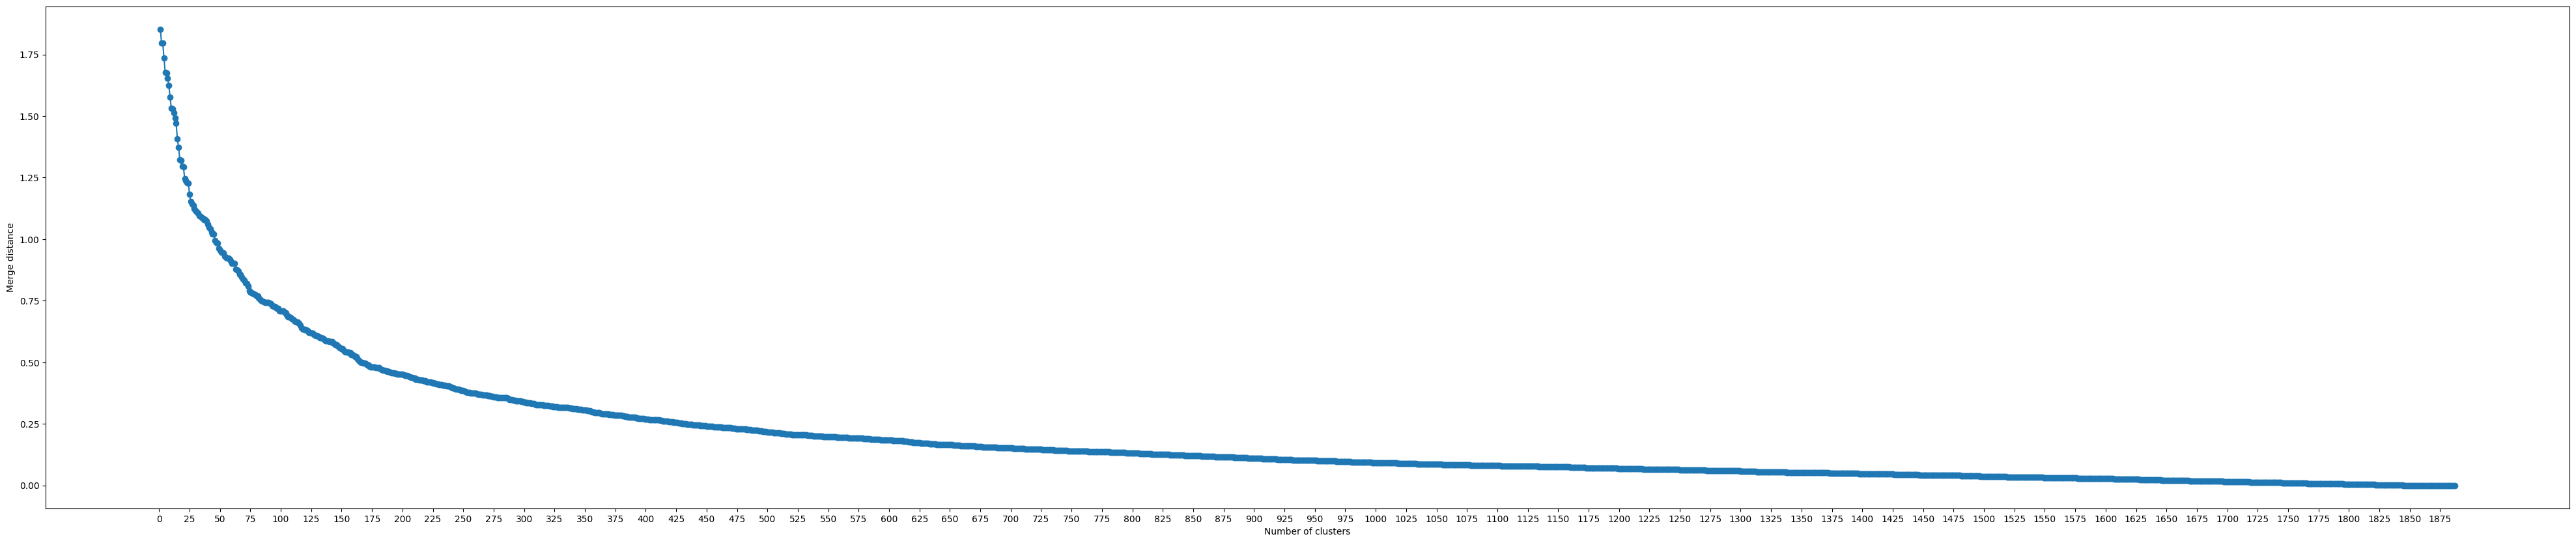

In [ ]:
plot_elbow(Complete_cosine, h=50, w=10)

In [ ]:
users_res = fcluster(Complete_cosine, t = 175, criterion='maxclust')
users_copy['complete_cosine_by_elbow'] = users_res

In [ ]:
silhouette_avg = silhouette_score(scaled_df, users_copy['complete_cosine_by_elbow'])
float(silhouette_avg)

-0.06390994995046897

In [ ]:
from scipy.cluster.hierarchy import inconsistent
from scipy.cluster.hierarchy import fcluster, maxinconsts

R = inconsistent(Complete_cosine, d=15) # d - глубина анализа (количество предыдущих шагов для оценки показателей)
MI = maxinconsts(Complete_cosine, R)

In [ ]:
res = fcluster(Complete_cosine, t=20, criterion='maxclust_monocrit', monocrit=MI)
df_copy['complete_cosine_maxclust_monocrit'] = res

In [ ]:
silhouette_avg = silhouette_score(reduced_df, df_copy['complete_cosine_maxclust_monocrit'])
float(silhouette_avg)

-0.03267229431712426

## KMeans

В качестве второго алгоритма был выбран KMeans, который хорошо подходит для разбиения данных на кластеры с центроидами, минимизирующими внутрикластерное расстояние.

In [ ]:
from sklearn.cluster import KMeans, BisectingKMeans, MiniBatchKMeans

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

Подмерем чесло кластеров в kmeans

## Метод локтя

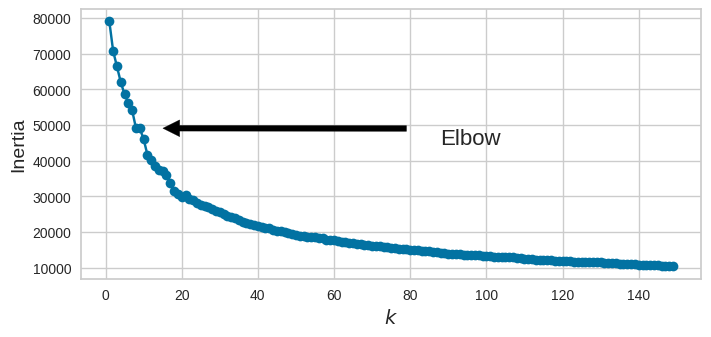

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=1, max_iter=100, random_state=23).fit(reduced_df)
                for k in range(1, 150)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 150), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
                 xy=(7, inertias[7]),
                 xytext=(0.55, 0.55),
                 textcoords='figure fraction',
                 fontsize=16,
                 arrowprops=dict(facecolor='black', shrink=0.1)
                )
plt.show()

На графике видно, что инерция перестает очень быстро падать в точке 8, 9 или 10. Такое же опитимальное значение мы получили в иерархической крастеризации, тогда было выявлено, что максимельное значение силуэта достигается при количестве кластеров равному 9.  

## Silhouette для выбора числа кластеров

Посмотрим на на индексы силуэта по каждому числу кластеров.  

In [ ]:
silhouette_scores = [silhouette_score(reduced_df, model.labels_)
                     for model in kmeans_per_k[1:]]

Выберем наиболее высокую точку на графике.

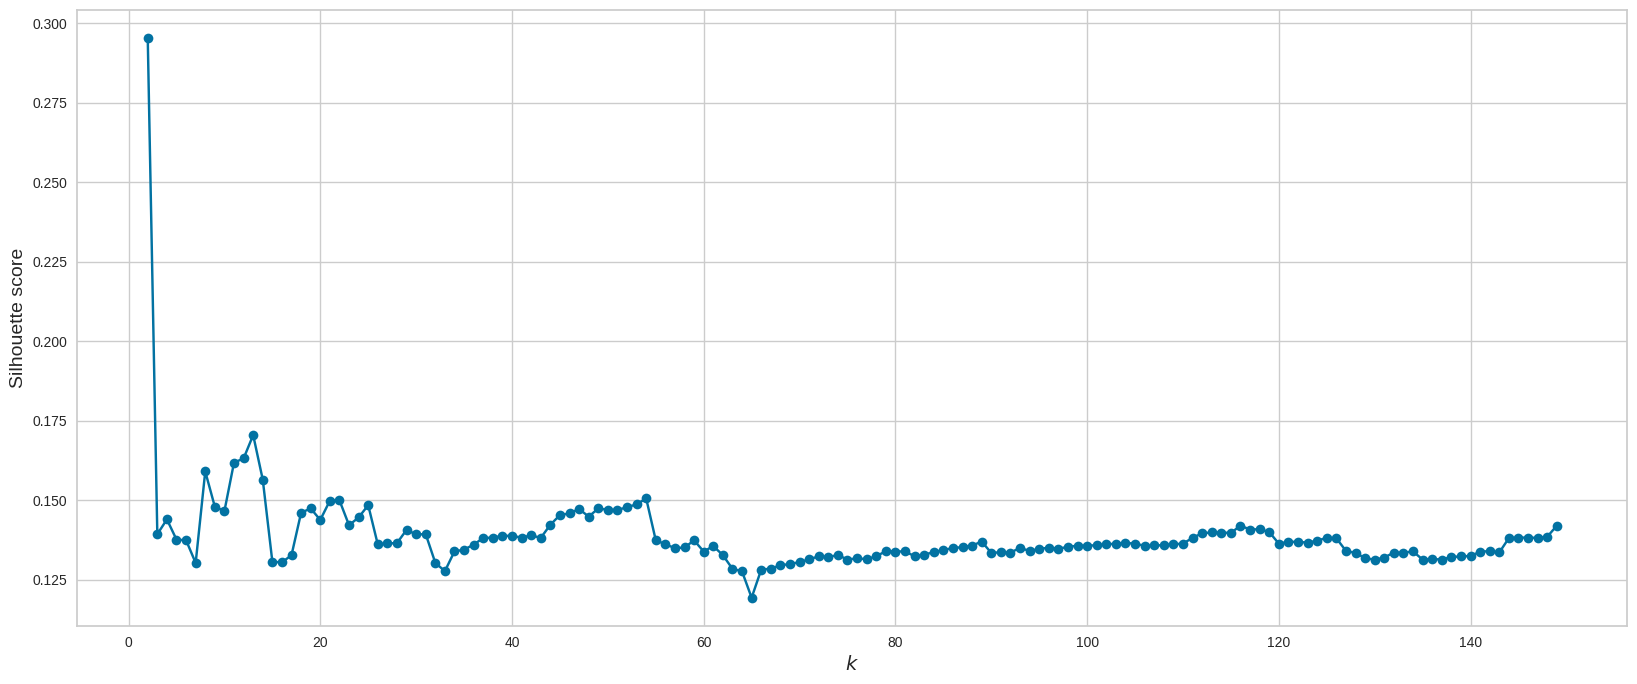

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(range(2, 150), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

Во-первых, индекс показывает, что k-means в целом плохо решает эту задачу.  
Во-вторых, видно, что 9 - не совсем оптимальное число кластеров по сравнению с  11 или 14

## Kmeans random

Попробуем выбрать центроиды кластеров случайно.

In [ ]:
KMns = KMeans(n_clusters = 3,
           init = 'random',
           n_init = 5,
           max_iter = 100,
           random_state=15434,
          )

In [ ]:
KMns.fit(reduced_df)

KMeans(init='random', max_iter=100, n_clusters=3, n_init=5, random_state=15434)

Построим силуэтный график, который показывает распределение коэффициентов силуэта для каждого объекта.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


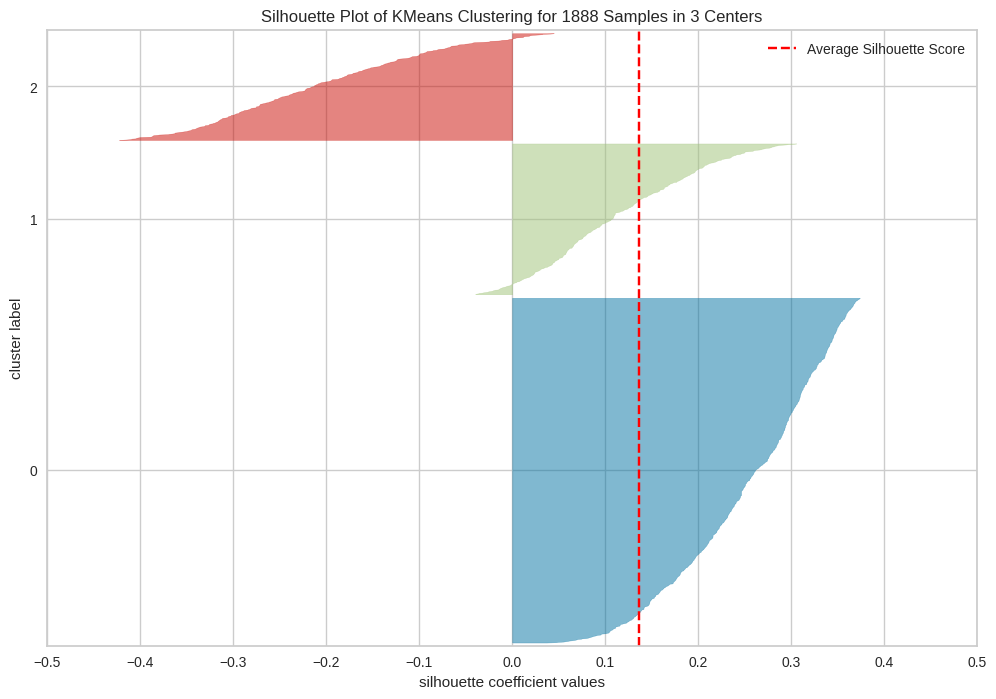

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1888 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
plt.figure(figsize=(12, 8))
visualizer = SilhouetteVisualizer(KMns, colors='yellowbrick')
visualizer.fit(reduced_df)
visualizer.show()

In [ ]:
silhouette_avg = silhouette_score(reduced_df, KMns.labels_)
print(silhouette_avg)

0.13672631011483702


In [ ]:
users_copy['kmeans (random) 11'] = KMns.labels_

In [ ]:
KMns14 = KMeans(n_clusters = 14,
           init = 'random',
           n_init = 5,
           max_iter = 100,
           random_state=24,
          )

In [ ]:
KMns14.fit(scaled_df)

KMeans(init='random', max_iter=100, n_clusters=14, n_init=5, random_state=24)

Построим силуэтный график, который показывает распределение коэффициентов силуэта для каждого объекта.

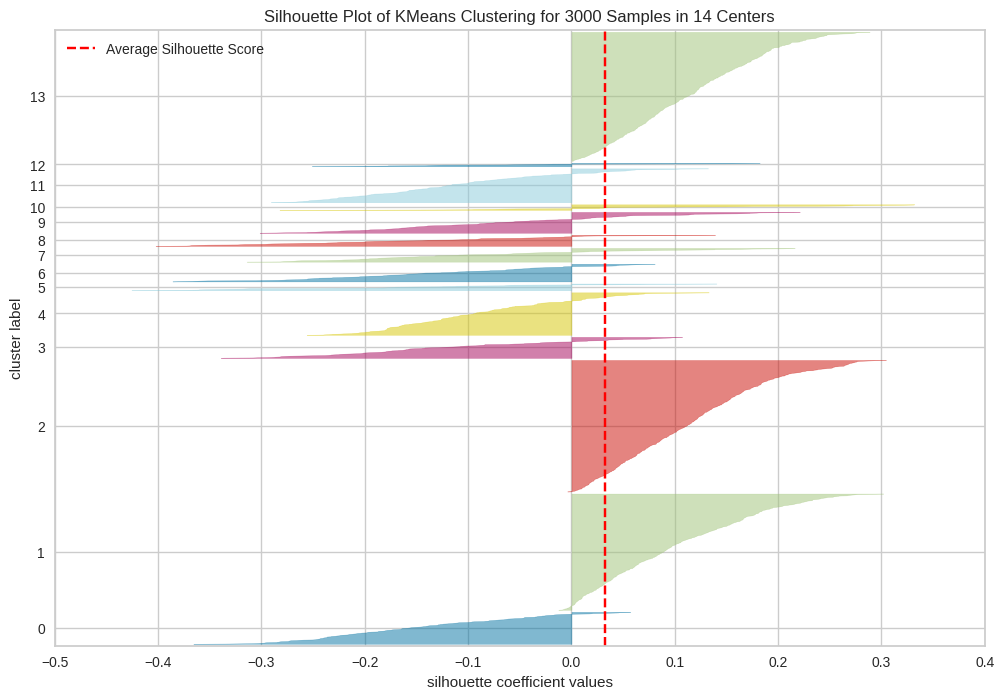

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 3000 Samples in 14 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
plt.figure(figsize=(12, 8))
visualizer = SilhouetteVisualizer(KMns14, colors='yellowbrick')
visualizer.fit(scaled_df)
visualizer.show()

In [ ]:
users_copy['kmeans (random) 14'] = KMns.labels_

## K-means++

 Попробуем инициализировать центроиды с помощью k-means++, который ищет такие центры кластеров (центроиды), чтобы минимизировать сумму квадратов расстояний от точек до ближайшего центра.

In [ ]:
KMns_plus = KMeans(n_clusters = 4,
           init = 'k-means++',
           n_init = 10,
           max_iter = 100,
           random_state=24)

KMns_plus.fit(reduced_df)

KMeans(max_iter=100, n_clusters=4, n_init=10, random_state=24)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


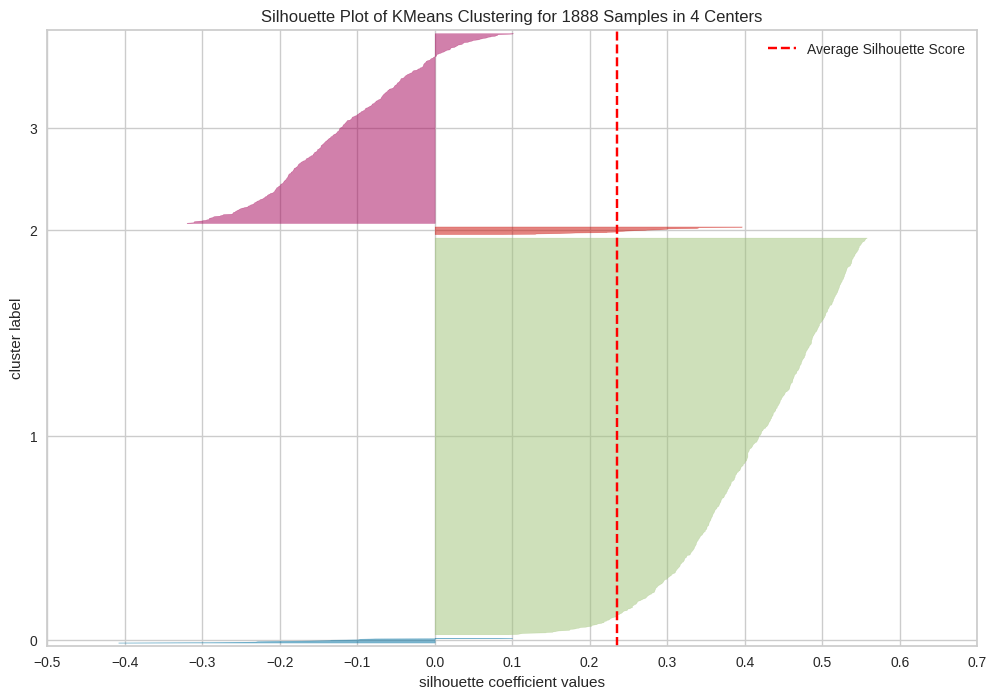

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1888 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
plt.figure(figsize=(12, 8))
visualizer = SilhouetteVisualizer(KMns_plus, colors='yellowbrick')
visualizer.fit(reduced_df)
visualizer.show()

In [ ]:
silhouette_avg = silhouette_score(reduced_df, KMns_plus.labels_)
print(silhouette_avg)

0.2355821913291209


In [ ]:
KMns_plus = KMeans(n_clusters = 4,
           init = 'k-means++',
           n_init = 10,
           max_iter = 100,
           random_state=24)

KMns_plus.fit(X_scaled_df)

KMeans(max_iter=100, n_clusters=4, n_init=10, random_state=24)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


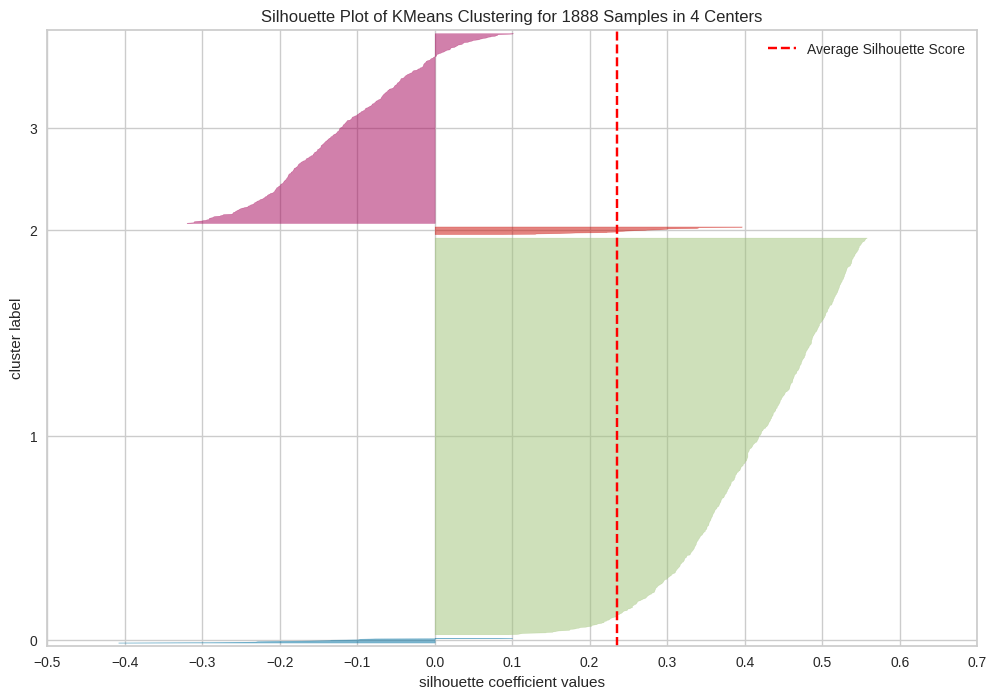

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1888 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
plt.figure(figsize=(12, 8))
visualizer = SilhouetteVisualizer(KMns_plus, colors='yellowbrick')
visualizer.fit(X_scaled_df)
visualizer.show()

In [ ]:
silhouette_avg = silhouette_score(X_scaled_df, KMns_plus.labels_)
print(silhouette_avg)

0.2355821913291209


# DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

In [ ]:
labels_db

array([-1, -1, -1, ..., -1, -1, -1])

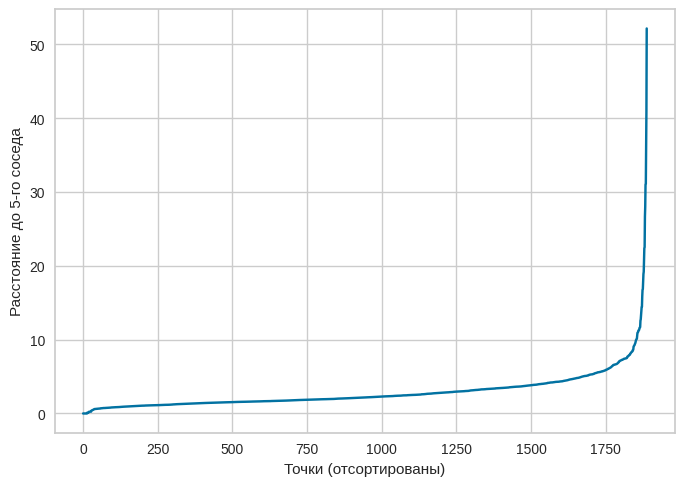

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

k_dist = np.sort(distances[:, 4], axis=0)
plt.plot(k_dist)
plt.xlabel('Точки (отсортированы)')
plt.ylabel('Расстояние до 5-го соседа')
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

eps = 2
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f'Найдено кластеров: {n_clusters}')
print(f'Количество шумовых точек: {n_noise}')

Найдено кластеров: 6
Количество шумовых точек: 982


In [ ]:
mask = labels != -1
if mask.sum() > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print(f'Силуэт для нешумовых точек: {score:.3f}')
else:
    print('Недостаточно кластерных точек для расчёта силуэта')

Силуэт для нешумовых точек: 0.184


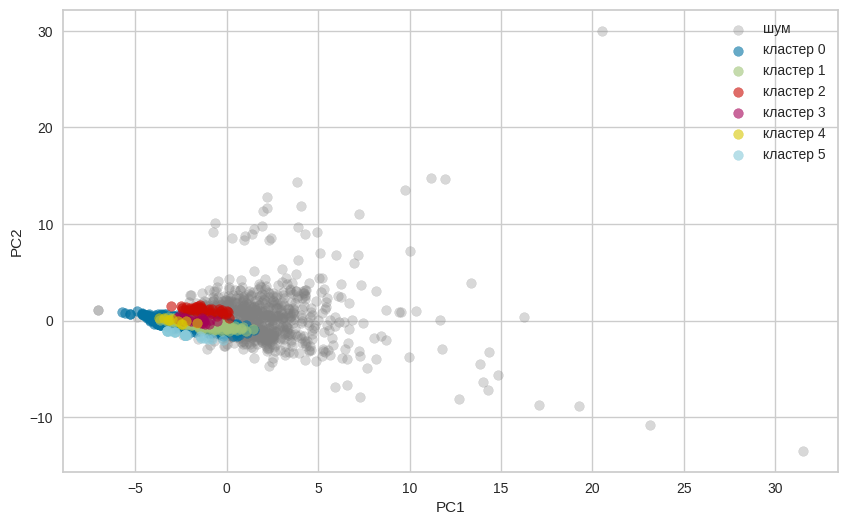

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[labels==-1, 0], X_pca[labels==-1, 1], c='gray', alpha=0.3, label='шум')
for cl in range(labels.max()+1):
    plt.scatter(X_pca[labels==cl, 0], X_pca[labels==cl, 1], alpha=0.6, label=f'кластер {cl}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()